In [56]:
# Export-Helferzelle für saubere HTML/PDF-Ausgabe

from IPython.display import HTML, display

display(HTML("""
<style>
h1, h2, h3, h4 {
    page-break-after: avoid !important;
    break-after: avoid-page !important;
}

table, thead, tbody, tr, th, td {
    page-break-inside: avoid !important;
    break-inside: avoid !important;
}

thead {
    display: table-header-group !important;
}

img {
    page-break-inside: avoid !important;
    break-inside: avoid-page !important;
    max-width: 100% !important;
    height: auto !important;
}

.jp-RenderedHTMLCommon,
.jp-OutputArea,
.jp-OutputArea-output,
.rendered_html,
.dataframe {
    page-break-inside: avoid !important;
    break-inside: avoid-page !important;
}
</style>
"""))

# P1 — Analyse der Auswirkungen zusätzlicher EV-Ladeleistungen auf ein Niederspannungsnetz

Dieses Notebook untersucht, wie zusätzliche Ladeleistungen von Elektrofahrzeugen ein typisches Niederspannungsnetz beeinflussen. Im Mittelpunkt stehen die Transformatorauslastung, die Leitungsauslastung und das Spannungsprofil unter verschiedenen EV-Szenarien.

Die Analyse ist szenariobasiert aufgebaut und dient als technisch nachvollziehbare Portfolioarbeit mit Python und pandapower. Neben der reinen Lastflussbewertung umfasst das Projekt auch einen vereinfachten Mitigationstest sowie einen Grenzpenetrationsansatz zur Abschätzung der technischen Aufnahmegrenze bei zunehmender EV-Integration.

Ziel ist eine klare, reproduzierbare Erstbewertung der Netzauswirkungen zusätzlicher EV-Ladeleistungen sowie eine kompakte technische Einordnung möglicher Gegenmaßnahmen.

## Inhaltsübersicht

Dieses Notebook ist wie folgt aufgebaut:

1. **Technische Fragestellung**  
   Ziel der Untersuchung und zentrale Bewertungsgrößen

2. **Netzmodell und Annahmen**  
   Verwendetes LV-Netz, Grundannahmen und Referenzfall

3. **Szenariodefinition und Gleichzeitigkeitsfaktor**  
   Definition der EV-Szenarien und Lastannahmen

4. **Lastflussberechnung und Ergebnistabellen**  
   Szenariovergleich, maßgebende Kennwerte und EV-Platzierung

5. **Vereinfachter Mitigationstest**  
   Vergleich zwischen Stressfall und vereinfachter Leistungsbegrenzung

6. **Grenzpenetration / Hosting-Capacity-Ansatz**  
   Abschätzung der ersten kritischen EV-Penetration ohne Mitigation

7. **Grenzpenetration mit Mitigation**  
   Vergleich der technischen Aufnahmegrenze mit reduzierter Wallbox-Leistung

8. **Visualisierungen**  
   Transformatorauslastung, Knotenspannung, Leitungsauslastung und Spannungsprofil

9. **Grenzen der Analyse**  
   Vereinfachungen, Annahmen und methodische Grenzen

10. **Fazit und nächste Schritte**  
    Zusammenfassung der Ergebnisse und möglicher Ausbau des Projekts

## 1. Technische Fragestellung

Untersucht wird, wie sich unterschiedliche EV-Szenarien mit verschiedenen Gleichzeitigkeitsfaktoren auf den Netzbetrieb auswirken. Im Fokus stehen dabei insbesondere die Transformatorauslastung, die maximale Leitungsauslastung und die minimale Knotenspannung.

In [29]:
import copy
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pandapower as pp
import pandapower.networks as nw
import pandapower.topology as top
import pandapower.plotting as pplot
import logging
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
pd.set_option("display.precision", 4)

In [30]:
from IPython.display import display, Markdown

def show_title(title, level=3):
    display(Markdown(f'{"#" * level} {title}'))

def show_table(df, fmt=None, text_cols=None, numeric_cols=None, hide_index=True):
    """
    df          : gösterilecek DataFrame
    fmt         : sütun bazlı sayı formatı, örn {"Trafo [%]": "{:.1f}"}
    text_cols   : sola hizalanacak metin sütunları
    numeric_cols: sağa hizalanacak sayısal sütunlar
    hide_index  : pandas index görünmesin mi
    """
    styler = df.style

    if fmt:
        styler = styler.format(fmt)

    if text_cols:
        styler = styler.set_properties(subset=text_cols, **{"text-align": "left"})

    if numeric_cols:
        styler = styler.set_properties(subset=numeric_cols, **{"text-align": "right"})

    styler = styler.set_table_styles([
        {"selector": "th", "props": [("text-align", "left")]},
        {"selector": "td", "props": [("padding", "4px 8px")]}
    ])

    if hide_index:
        styler = styler.hide(axis="index")

    display(styler)

In [31]:
from pathlib import Path

def find_project_root():
    current = Path.cwd().resolve()

    candidates = [current, current.parent]

    for candidate in candidates:
        if (candidate / "results").exists() and (candidate / "README.md").exists():
            return candidate

    raise FileNotFoundError(
        "Projektwurzel konnte nicht gefunden werden. "
        "Bitte Notebook aus dem Projektordner oder dem notebooks/-Ordner starten."
    )

PROJECT_ROOT = find_project_root()
RESULTS_DIR = PROJECT_ROOT / "results"
TABLES_DIR = RESULTS_DIR / "tables"
FIGURES_DIR = RESULTS_DIR / "figures"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def export_table(df, filename, index=False):
    path = TABLES_DIR / filename
    df.to_csv(path, index=index, encoding="utf-8-sig")
    # print(f"Gespeichert: {path.relative_to(PROJECT_ROOT)}")
    return path

def export_figure(filename, dpi=150):
    path = FIGURES_DIR / filename
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    # print(f"Gespeichert: {path.relative_to(PROJECT_ROOT)}")
    return path

## 2. Netzmodell und Annahmen

Als Beispielnetz wird `create_kerber_dorfnetz()` aus pandapower verwendet. Es handelt sich nicht um ein reales Netzmodell, sondern um ein repräsentatives Niederspannungsnetz für eine nachvollziehbare, reproduzierbare Szenarioanalyse. Zusätzliche EV-Lasten werden als vereinfachte Wallbox-Lasten mit 11 kW modelliert.

> **Wichtiger Einordnungshinweis zum Referenzfall:**  
> Das verwendete Kerber-Dorfnetz ist ein **repräsentatives pandapower-Testnetz** und **kein real kalibriertes Netz** eines konkreten Netzbetreibers. Deshalb ist für die technische Einordnung in diesem Projekt vor allem die **relative Veränderung** zwischen Referenzfall, EV-Szenarien, Mitigation und Grenzpenetration relevant.  
> Insbesondere ein im Referenzfall bereits vergleichsweise hohes Ausgangsniveau der **Transformatorauslastung** ist hier **nicht als standortspezifische Realnetzaussage** zu verstehen, sondern als Eigenschaft des verwendeten Testnetzes. Für die Bewertung sind daher die **Δ-Effekte** und die Verschiebung der maßgebenden Kennwerte aussagekräftiger als die absolute Plausibilisierung eines einzelnen Startwerts.
> **Annahme zur Blindleistung:** Die zusätzlich modellierten EV-Ladeleistungen werden in dieser Portfolioanalyse als rein wirkleistungsseitige Zusatzlasten angesetzt (`q_mvar = 0`). Ein möglicher Blindleistungsanteil realer Ladeeinrichtungen wird damit nicht abgebildet. Diese Vereinfachung dient der klaren Vergleichbarkeit der Szenarien und der Fokussierung auf die Auswirkungen zusätzlicher Ladeleistung auf Transformatorauslastung, Leitungsauslastung und Spannungsniveau.

In [32]:
# Basisnetz
base_net = nw.create_kerber_dorfnetz()
pp.runpp(base_net)

candidate_buses = sorted(base_net.load.bus.unique().tolist())
lv_bus = int(base_net.trafo.lv_bus.iloc[0])
hv_bus = int(base_net.trafo.hv_bus.iloc[0])

show_title("Netzüberblick")

net_overview_df = pd.DataFrame({
    "Kennwert": [
        "Anzahl Busse",
        "Anzahl Leitungen",
        "Anzahl Lasten",
        "Anzahl Transformatoren",
        "Anzahl externer Einspeisungen",
        "Anzahl EV-Kandidatenbusse",
        "Trafo-HV-Bus",
        "Trafo-LV-Bus"
    ],
    "Wert": [
        len(base_net.bus),
        len(base_net.line),
        len(base_net.load),
        len(base_net.trafo),
        len(base_net.ext_grid),
        len(candidate_buses),
        hv_bus,
        lv_bus
    ]
})

show_table(
    net_overview_df,
    text_cols=["Kennwert"],
    numeric_cols=["Wert"]
)

show_title("Kennwerte des Referenzfalls")

reference_kpi_df = pd.DataFrame({
    "Kenngröße": [
        "Minimale Spannung [pu]",
        "Maximale Leitungsauslastung [%]",
        "Transformatorauslastung [%]"
    ],
    "Wert": [
        base_net.res_bus.vm_pu.min(),
        base_net.res_line.loading_percent.max(),
        base_net.res_trafo.loading_percent.max()
    ]
})

show_table(
    reference_kpi_df,
    fmt={"Wert": "{:.4f}"},
    text_cols=["Kenngröße"],
    numeric_cols=["Wert"]
)

show_title("Beispielhafte Lastknoten (erste 5 Zeilen)")

load_cols = ["name", "bus", "p_mw", "q_mvar", "scaling", "in_service"]

load_display_df = (
    base_net.load.loc[:, [c for c in load_cols if c in base_net.load.columns]]
    .head()
    .rename(columns={
        "name": "Bezeichnung",
        "bus": "Bus",
        "p_mw": "P [MW]",
        "q_mvar": "Q [MVAr]",
        "scaling": "Skalierung",
        "in_service": "In Betrieb"
    })
)

if "Bezeichnung" in load_display_df.columns:
    load_display_df["Bezeichnung"] = load_display_df["Bezeichnung"].fillna(
        "Last_" + load_display_df["Bus"].astype(str)
    )

if "In Betrieb" in load_display_df.columns:
    load_display_df["In Betrieb"] = load_display_df["In Betrieb"].map({True: "Ja", False: "Nein"})

show_table(
    load_display_df,
    fmt={
        "P [MW]": "{:.3f}",
        "Q [MVAr]": "{:.3f}",
        "Skalierung": "{:.1f}"
    },
    text_cols=["Bezeichnung", "In Betrieb"],
    numeric_cols=[c for c in ["Bus", "P [MW]", "Q [MVAr]", "Skalierung"] if c in load_display_df.columns]
)

show_title("Beispielhafte Busse (erste 5 Zeilen)")

bus_cols = ["name", "vn_kv", "type", "in_service"]

bus_display_df = (
    base_net.bus.loc[:, [c for c in bus_cols if c in base_net.bus.columns]]
    .head()
    .rename(columns={
        "name": "Bezeichnung",
        "vn_kv": "Nennspannung [kV]",
        "type": "Typ",
        "in_service": "In Betrieb"
    })
)

if "In Betrieb" in bus_display_df.columns:
    bus_display_df["In Betrieb"] = bus_display_df["In Betrieb"].map({True: "Ja", False: "Nein"})

show_table(
    bus_display_df,
    fmt={"Nennspannung [kV]": "{:.1f}"},
    text_cols=["Bezeichnung", "Typ", "In Betrieb"],
    numeric_cols=["Nennspannung [kV]"]
)

### Netzüberblick

Kennwert,Wert
Anzahl Busse,116
Anzahl Leitungen,114
Anzahl Lasten,57
Anzahl Transformatoren,1
Anzahl externer Einspeisungen,1
Anzahl EV-Kandidatenbusse,57
Trafo-HV-Bus,0
Trafo-LV-Bus,1


### Kennwerte des Referenzfalls

Kenngröße,Wert
Minimale Spannung [pu],0.9550
Maximale Leitungsauslastung [%],52.2099
Transformatorauslastung [%],88.0487


### Beispielhafte Lastknoten (erste 5 Zeilen)

Bezeichnung,Bus,P [MW],Q [MVAr],Skalierung,In Betrieb
Last_3,3,0.006,0.000,1.0,Ja
Last_5,5,0.006,0.000,1.0,Ja
Last_7,7,0.006,0.000,1.0,Ja
Last_9,9,0.006,0.000,1.0,Ja
Last_11,11,0.006,0.000,1.0,Ja


### Beispielhafte Busse (erste 5 Zeilen)

Bezeichnung,Nennspannung [kV],Typ,In Betrieb
Trafostation_OS,10.0,b,Ja
main_busbar,0.4,b,Ja
MUF_1_1,0.4,n,Ja
loadbus_1_1,0.4,b,Ja
KV_1_2,0.4,b,Ja


### Topologische Ansicht des Referenznetzes

Die folgende Abbildung zeigt eine vereinfachte topologische Darstellung des verwendeten Kerber-Dorfnetzes. Ziel ist keine geographische Abbildung eines realen Versorgungsgebiets, sondern eine visuelle Einordnung der Netzstruktur des verwendeten Referenzmodells.

### Topologische Ansicht des Referenznetzes

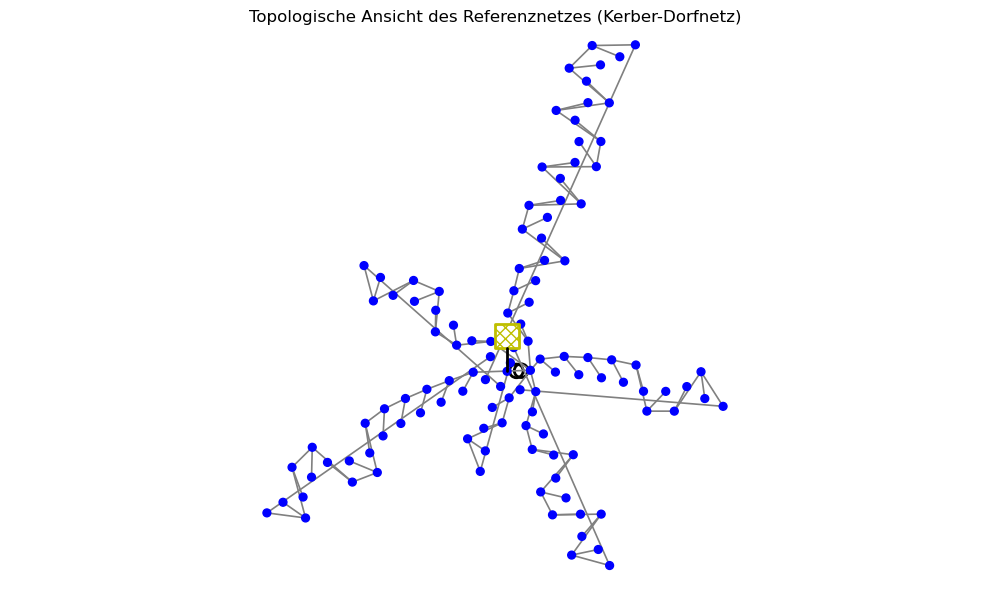

In [33]:
show_title("Topologische Ansicht des Referenznetzes")

try:
    # störende geodata-Warnung für die Notebook-Ausgabe unterdrücken
    logging.getLogger("pandapower.plotting.simple_plot").setLevel(logging.ERROR)

    plt.figure(figsize=(10, 6))
    ax = plt.gca()

    pplot.simple_plot(
        base_net,
        respect_switches=True,
        line_width=1.2,
        bus_size=0.8,
        ext_grid_size=1.6,
        trafo_size=1.4,
        plot_loads=False,
        plot_gens=False,
        plot_sgens=False,
        plot_line_switches=False,
        scale_size=True,
        library="networkx",
        show_plot=False,
        ax=ax
    )

    plt.title("Topologische Ansicht des Referenznetzes (Kerber-Dorfnetz)")
    plt.tight_layout()
    export_figure("netz_topologie_referenz.png")
    plt.show()

except Exception as e:
    plt.close("all")
    display(Markdown(
        f"**Hinweis zur Topologie-Visualisierung:** "
        f"Die vereinfachte Netzgrafik konnte in der aktuellen Umgebung nicht erzeugt werden. "
        f"Für diese Darstellung werden zusätzliche optionale Visualisierungsabhängigkeiten benötigt "
        f"(z. B. `graphviz` / `pygraphviz`). "
        f"Die eigentliche Netzanalyse des Projekts ist davon nicht betroffen.\n\n"
        f"`Fehlermeldung: {type(e).__name__}: {e}`"
    ))

In [34]:
def get_candidate_buses(net):
    """
    Kandidatenbusse für zusätzliche EV-Lasten: eindeutige Busse mit bereits vorhandenen Lasten
    """
    return sorted(net.load.bus.unique().tolist())


def evenly_spaced_selection(items, n):
    """
    Deterministische Auswahl mit ungefähr gleichmäßiger Verteilung. Es wird keine Zufallsauswahl verwendet.
    """
    if n <= 0:
        return []
    if n >= len(items):
        return list(items)

    step = len(items) / n
    selected = []
    used_indices = set()

    for i in range(n):
        idx = min(int(i * step), len(items) - 1)

        while idx in used_indices and idx < len(items) - 1:
            idx += 1

        used_indices.add(idx)
        selected.append(items[idx])

    return selected


def select_ev_buses(base_net, ev_count, placement):
    """
    Platzierungslogik für zusätzliche EV-Lasten:
    - distributed: verteilte Zuordnung auf Kandidatenbusse
    - remote_end: Auswahl der Busse mit der niedrigsten Spannung im Referenzfall
    """
    candidate_buses = get_candidate_buses(base_net)

    if ev_count <= 0:
        return []

    if placement == "distributed":
        return evenly_spaced_selection(candidate_buses, ev_count)

    elif placement == "remote_end":
        ranked_buses = (
            base_net.res_bus.loc[candidate_buses, ["vm_pu"]]
            .sort_values("vm_pu", ascending=True)
            .index
            .tolist()
        )
        return ranked_buses[:ev_count]

    else:
        raise ValueError(f"Unbekannter Platzierungstyp: {placement}")


def classify_status(min_vm_pu, max_line_loading, trafo_loading):
    """
    Vereinfachte Bewertungslogik:
    - Critical
    - Warning
    - OK
    """
    if (min_vm_pu < 0.90) or (max_line_loading > 100) or (trafo_loading > 100):
        return "Critical"

    if (min_vm_pu < 0.95) or (max_line_loading > 80):
        return "Warning"

    return "OK"


def make_comment(min_vm_pu, max_line_loading, trafo_loading):
    comments = []

    if min_vm_pu < 0.90:
        comments.append("voltage below 0.90 pu")
    elif min_vm_pu < 0.95:
        comments.append("voltage below 0.95 pu")

    if max_line_loading > 100:
        comments.append("line overload >100%")
    elif max_line_loading > 80:
        comments.append("line loading >80%")

    if trafo_loading > 100:
        comments.append("transformer overload >100%")

    if not comments:
        return "No critical issue in V1 assessment"

    return "; ".join(comments)

## 3. Szenariodefinition und Gleichzeitigkeitsfaktor

Die Untersuchung basiert auf vier Szenarien: Referenzfall, moderate EV-Integration, erhöhte EV-Integration und Stressfall. Variiert werden dabei vor allem der EV-Anteil, der Gleichzeitigkeitsfaktor und die räumliche Platzierung der zusätzlichen Ladepunkte.

**Einordnung der Gleichzeitigkeitsfaktoren (vereinfachte Szenarioannahme):**  
Die in diesem Projekt verwendeten Gleichzeitigkeitsfaktoren von **0,3 / 0,6 / 1,0** sind **keine normativ festgelegten Einzelwerte** aus der **VDE-AR-N 4100**, sondern werden hier als **vereinfachte, praxisnahe Szenariowerte** verwendet, um niedrige, mittlere und hohe Gleichzeitigkeit zusätzlicher EV-Ladevorgänge abzubilden. Fachlich orientiert sich diese Einordnung an der allgemeinen Logik aus **VDE/FNN- und BDEW-Kontexten**: Für die Netzbewertung ist insbesondere die **zeitliche Überlagerung von Ladevorgängen und sonstigen Lasten** relevant; ohne Leistungsmanagement wird für einzelne Ladepunkte bzw. Stromkreise konservativ mit hoher Gleichzeitigkeit gerechnet, während vorhandenes **Leistungsmanagement** die anzusetzende Gleichzeitigkeit reduzieren kann. Im vorliegenden Projekt dienen die Werte daher nicht als normativer Nachweis, sondern als **transparent gewählte Szenarioannahmen** für eine nachvollziehbare Portfolioanalyse.

In [35]:
SCENARIOS = {
    "S0_Base": {
        "penetration": 0.00,
        "gf": 0.00,
        "placement": "distributed",
        "wallbox_kw": 11
    },
    "S1_Moderate": {
        "penetration": 0.20,
        "gf": 0.30,
        "placement": "distributed",
        "wallbox_kw": 11
    },
    "S2_Elevated": {
        "penetration": 0.50,
        "gf": 0.60,
        "placement": "distributed",
        "wallbox_kw": 11
    },
    "S3_Stress": {
        "penetration": 0.80,
        "gf": 1.00,
        "placement": "remote_end",
        "wallbox_kw": 11
    },
    "S3_Mitigation": {
        "penetration": 0.80,
        "gf": 1.00,
        "placement": "remote_end",
        "wallbox_kw": 7
    }
}

scenario_display_df = pd.DataFrame(SCENARIOS).T.reset_index().rename(columns={
    "index": "Szenario",
    "penetration": "EV-Anteil [-]",
    "gf": "Gleichzeitigkeitsfaktor [-]",
    "placement": "Platzierung",
    "wallbox_kw": "Wallbox-Leistung [kW]"
})

scenario_display_df["Szenario"] = scenario_display_df["Szenario"].replace({
    "S0_Base": "S0 — Referenzfall",
    "S1_Moderate": "S1 — Moderate EV-Integration",
    "S2_Elevated": "S2 — Erhöhte EV-Integration",
    "S3_Stress": "S3 — Stressfall",
    "S3_Mitigation": "S3 — Mitigation (7 kW)"
})

scenario_display_df["Platzierung"] = scenario_display_df["Platzierung"].replace({
    "distributed": "verteilt",
    "remote_end": "entferntes Netzende"
})

show_title("Szenariodefinitionen")

show_table(
    scenario_display_df,
    fmt={
        "EV-Anteil [-]": "{:.2f}",
        "Gleichzeitigkeitsfaktor [-]": "{:.2f}",
        "Wallbox-Leistung [kW]": "{:.0f}"
    },
    text_cols=["Szenario", "Platzierung"],
    numeric_cols=["EV-Anteil [-]", "Gleichzeitigkeitsfaktor [-]", "Wallbox-Leistung [kW]"]
)

### Szenariodefinitionen

Szenario,EV-Anteil [-],Gleichzeitigkeitsfaktor [-],Platzierung,Wallbox-Leistung [kW]
S0 — Referenzfall,0.00,0.00,verteilt,11
S1 — Moderate EV-Integration,0.20,0.30,verteilt,11
S2 — Erhöhte EV-Integration,0.50,0.60,verteilt,11
S3 — Stressfall,0.80,1.00,entferntes Netzende,11
S3 — Mitigation (7 kW),0.80,1.00,entferntes Netzende,7


### Visualisierung des Gleichzeitigkeitsfaktors

Die folgende Abbildung zeigt die angesetzten Gleichzeitigkeitsfaktoren der definierten Szenarien. Damit wird die Szenariologik zwischen Referenzfall, moderater EV-Integration, erhöhter EV-Integration und Stressfall kompakt visualisiert.

### Visualisierung — Gleichzeitigkeitsfaktor je Szenario

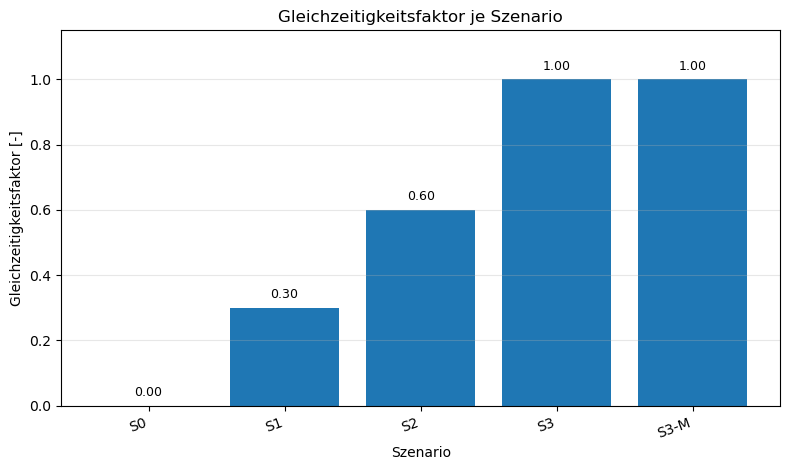

In [36]:
show_title("Visualisierung — Gleichzeitigkeitsfaktor je Szenario")

gf_plot_df = scenario_display_df.copy()

scenario_order = [
    "S0 — Referenzfall",
    "S1 — Moderate EV-Integration",
    "S2 — Erhöhte EV-Integration",
    "S3 — Stressfall",
    "S3 — Mitigation (7 kW)"
]

gf_plot_df["Szenario"] = pd.Categorical(
    gf_plot_df["Szenario"],
    categories=scenario_order,
    ordered=True
)
gf_plot_df = gf_plot_df.sort_values("Szenario").reset_index(drop=True)

gf_plot_df["Kurzlabel"] = ["S0", "S1", "S2", "S3", "S3-M"]

plt.figure(figsize=(8, 4.8))
bars = plt.bar(
    gf_plot_df["Kurzlabel"],
    gf_plot_df["Gleichzeitigkeitsfaktor [-]"]
)

for bar, value in zip(bars, gf_plot_df["Gleichzeitigkeitsfaktor [-]"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.03,
        f"{value:.2f}",
        ha="center",
        fontsize=9
    )

plt.ylim(0, 1.15)
plt.title("Gleichzeitigkeitsfaktor je Szenario")
plt.xlabel("Szenario")
plt.ylabel("Gleichzeitigkeitsfaktor [-]")
plt.grid(axis="y", alpha=0.3)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
export_figure("gleichzeitigkeitsfaktor_szenarien.png")
plt.show()

In [37]:
def run_ev_scenario(base_net, scenario_name, config):
    """
    Erstellt ein EV-Szenario auf einer Kopie des Referenznetzes,
    führt die Lastflussberechnung durch und gibt zentrale Kennwerte zurück.
    """
    net = copy.deepcopy(base_net)

    candidate_buses = get_candidate_buses(base_net)
    candidate_count = len(candidate_buses)

    penetration = config["penetration"]
    gf = config["gf"]
    placement = config["placement"]
    wallbox_kw = config["wallbox_kw"]

    ev_count = math.ceil(candidate_count * penetration) if penetration > 0 else 0
    selected_buses = select_ev_buses(base_net, ev_count, placement)

    ev_p_mw_per_bus = (wallbox_kw / 1000.0) * gf

    # Zusätzliche EV-Lasten hinzufügen
    for i, bus in enumerate(selected_buses, start=1):
        pp.create_load(
            net,
            bus=int(bus),
            p_mw=ev_p_mw_per_bus,
            q_mvar=0.0,
            name=f"EV_{scenario_name}_{i}"
        )

    # Power flow
    pp.runpp(net)

    # Zentrale Kennwerte
    min_bus_idx = int(net.res_bus.vm_pu.idxmin())
    min_vm_pu = float(net.res_bus.vm_pu.loc[min_bus_idx])

    max_line_idx = int(net.res_line.loading_percent.idxmax())
    max_line_loading = float(net.res_line.loading_percent.loc[max_line_idx])

    max_trafo_idx = int(net.res_trafo.loading_percent.idxmax())
    trafo_loading = float(net.res_trafo.loading_percent.loc[max_trafo_idx])

    status = classify_status(min_vm_pu, max_line_loading, trafo_loading)
    comment = make_comment(min_vm_pu, max_line_loading, trafo_loading)

    summary_row = {
        "scenario": scenario_name,
        "penetration": penetration,
        "candidate_bus_count": candidate_count,
        "ev_count": ev_count,
        "wallbox_kw": wallbox_kw,
        "gf": gf,
        "placement": placement,
        "total_ev_load_kw": ev_count * wallbox_kw * gf,
        "transformer_loading_percent": trafo_loading,
        "max_line_loading_percent": max_line_loading,
        "min_bus_voltage_pu": min_vm_pu,
        "status": status,
        "comment": comment
    }

    critical_rows = [
        {
            "scenario": scenario_name,
            "element_type": "transformer",
            "element_index": max_trafo_idx,
            "element_name": str(net.trafo.at[max_trafo_idx, "name"]) if "name" in net.trafo.columns else f"trafo_{max_trafo_idx}",
            "metric": "loading_percent",
            "value": trafo_loading
        },
        {
            "scenario": scenario_name,
            "element_type": "line",
            "element_index": max_line_idx,
            "element_name": str(net.line.at[max_line_idx, "name"]) if "name" in net.line.columns else f"line_{max_line_idx}",
            "metric": "loading_percent",
            "value": max_line_loading
        },
        {
            "scenario": scenario_name,
            "element_type": "bus",
            "element_index": min_bus_idx,
            "element_name": str(net.bus.at[min_bus_idx, "name"]) if "name" in net.bus.columns else f"bus_{min_bus_idx}",
            "metric": "vm_pu",
            "value": min_vm_pu
        }
    ]

    return net, summary_row, critical_rows, selected_buses

## 4. Lastflussberechnung und Ergebnistabellen

Für jedes Szenario wird eine Lastflussberechnung durchgeführt. Anschließend werden die wichtigsten Kenngrößen in kompakten Ergebnistabellen zusammengefasst, damit die Unterschiede zwischen den Szenarien direkt vergleichbar sind.

In [38]:
scenario_nets = {}
scenario_rows = []
critical_rows_all = []
selected_bus_map = {}

for scenario_name, config in SCENARIOS.items():
    net_sc, summary_row, critical_rows, selected_buses = run_ev_scenario(base_net, scenario_name, config)

    scenario_nets[scenario_name] = net_sc
    scenario_rows.append(summary_row)
    critical_rows_all.extend(critical_rows)
    selected_bus_map[scenario_name] = selected_buses

# Interne Datenstrukturen bleiben auf Englisch
scenario_summary_df = pd.DataFrame(scenario_rows)
critical_elements_df = pd.DataFrame(critical_rows_all)

# Deutsche Anzeige-Bezeichnungen für Szenarien
scenario_label_map = {
    "S0_Base": "S0 — Referenzfall",
    "S1_Moderate": "S1 — Moderate EV-Integration",
    "S2_Elevated": "S2 — Erhöhte EV-Integration",
    "S3_Stress": "S3 — Stressfall",
    "S3_Mitigation": "S3 — Mitigation (7 kW)"
}

# Für die Ausgabe werden deutsche Anzeigetabellen erzeugt
scenario_summary_display_df = scenario_summary_df.copy().rename(columns={
    "scenario": "Szenario",
    "penetration": "EV-Anteil",
    "candidate_bus_count": "Kandidatenbusse",
    "ev_count": "EV",
    "wallbox_kw": "Wallbox [kW]",
    "gf": "GF",
    "placement": "Platzierung",
    "total_ev_load_kw": "EV-Last [kW]",
    "transformer_loading_percent": "Trafo [%]",
    "max_line_loading_percent": "Max. Leitung [%]",
    "min_bus_voltage_pu": "Min. U [pu]",
    "status": "Bewertung",
    "comment": "Kommentar"
})

scenario_summary_display_df["Szenario"] = scenario_summary_display_df["Szenario"].replace(scenario_label_map)

scenario_summary_display_df["Platzierung"] = scenario_summary_display_df["Platzierung"].replace({
    "distributed": "verteilt",
    "remote_end": "Netzende"
})

scenario_summary_display_df["Bewertung"] = scenario_summary_display_df["Bewertung"].replace({
    "Critical": "Kritisch",
    "Warning": "Warnung",
    "OK": "Unkritisch"
})

scenario_summary_display_df["Kommentar"] = (
    scenario_summary_display_df["Kommentar"]
    .str.replace("voltage below 0.90 pu", "U < 0,90 pu", regex=False)
    .str.replace("voltage below 0.95 pu", "U < 0,95 pu", regex=False)
    .str.replace("line overload >100%", "Leitung > 100 %", regex=False)
    .str.replace("line loading >80%", "Leitung > 80 %", regex=False)
    .str.replace("transformer overload >100%", "Trafo > 100 %", regex=False)
    .str.replace("No critical issue in V1 assessment", "Keine kritische Auffälligkeit", regex=False)
)

# Kompakte Anzeige für das Notebook
scenario_summary_display_df["EV-Anteil"] = scenario_summary_display_df["EV-Anteil"].round(2)
scenario_summary_display_df["Trafo [%]"] = scenario_summary_display_df["Trafo [%]"].round(1)
scenario_summary_display_df["Max. Leitung [%]"] = scenario_summary_display_df["Max. Leitung [%]"].round(1)
scenario_summary_display_df["Min. U [pu]"] = scenario_summary_display_df["Min. U [pu]"].round(4)
scenario_summary_display_df["EV-Last [kW]"] = scenario_summary_display_df["EV-Last [kW]"].round(1)

scenario_summary_display_df = scenario_summary_display_df[
    [
        "Szenario",
        "EV-Anteil",
        "EV",
        "GF",
        "Platzierung",
        "EV-Last [kW]",
        "Trafo [%]",
        "Max. Leitung [%]",
        "Min. U [pu]",
        "Bewertung"
    ]
]

critical_elements_display_df = critical_elements_df.copy().rename(columns={
    "scenario": "Szenario",
    "element_type": "Elementtyp",
    "element_index": "Index",
    "element_name": "Element",
    "metric": "Kenngröße",
    "value": "Wert"
})

critical_elements_display_df["Szenario"] = critical_elements_display_df["Szenario"].replace(scenario_label_map)

critical_elements_display_df["Elementtyp"] = critical_elements_display_df["Elementtyp"].replace({
    "transformer": "Transformator",
    "line": "Leitung",
    "bus": "Bus"
})

critical_elements_display_df["Kenngröße"] = critical_elements_display_df["Kenngröße"].replace({
    "loading_percent": "Auslastung [%]",
    "vm_pu": "Spannung [pu]"
})

critical_elements_display_df["Wert"] = critical_elements_display_df["Wert"].round(4)

critical_elements_display_df = critical_elements_display_df[
    ["Szenario", "Elementtyp", "Element", "Kenngröße", "Wert"]
]

show_title("Szenarioübersicht")

show_table(
    scenario_summary_display_df,
    fmt={
        "EV-Anteil": "{:.2f}",
        "GF": "{:.2f}",
        "EV-Last [kW]": "{:.1f}",
        "Trafo [%]": "{:.1f}",
        "Max. Leitung [%]": "{:.1f}",
        "Min. U [pu]": "{:.4f}"
    },
    text_cols=["Szenario", "Platzierung", "Bewertung"],
    numeric_cols=["EV-Anteil", "EV", "GF", "EV-Last [kW]", "Trafo [%]", "Max. Leitung [%]", "Min. U [pu]"]
)

base_row = scenario_summary_df[
    scenario_summary_df["scenario"] == "S0_Base"
].iloc[0]

delta_vs_base_df = (
    scenario_summary_df[
        scenario_summary_df["scenario"] != "S0_Base"
    ][[
        "scenario",
        "total_ev_load_kw",
        "transformer_loading_percent",
        "max_line_loading_percent",
        "min_bus_voltage_pu"
    ]]
    .copy()
)

delta_vs_base_df["Szenario"] = delta_vs_base_df["scenario"].replace(scenario_label_map)

delta_vs_base_df["Δ EV-Last [kW] vs. S0"] = (
    delta_vs_base_df["total_ev_load_kw"] - base_row["total_ev_load_kw"]
)

delta_vs_base_df["Δ Trafo [%] vs. S0"] = (
    delta_vs_base_df["transformer_loading_percent"] - base_row["transformer_loading_percent"]
)

delta_vs_base_df["Δ Max. Leitung [%] vs. S0"] = (
    delta_vs_base_df["max_line_loading_percent"] - base_row["max_line_loading_percent"]
)

delta_vs_base_df["Δ Min. U [pu] vs. S0"] = (
    delta_vs_base_df["min_bus_voltage_pu"] - base_row["min_bus_voltage_pu"]
)

delta_vs_base_df = delta_vs_base_df[
    [
        "Szenario",
        "Δ EV-Last [kW] vs. S0",
        "Δ Trafo [%] vs. S0",
        "Δ Max. Leitung [%] vs. S0",
        "Δ Min. U [pu] vs. S0"
    ]
]

show_title("Delta gegenüber dem Referenzfall (S0)")

show_table(
    delta_vs_base_df,
    fmt={
        "Δ EV-Last [kW] vs. S0": "{:+.1f}",
        "Δ Trafo [%] vs. S0": "{:+.1f}",
        "Δ Max. Leitung [%] vs. S0": "{:+.1f}",
        "Δ Min. U [pu] vs. S0": "{:+.4f}"
    },
    text_cols=["Szenario"],
    numeric_cols=[
        "Δ EV-Last [kW] vs. S0",
        "Δ Trafo [%] vs. S0",
        "Δ Max. Leitung [%] vs. S0",
        "Δ Min. U [pu] vs. S0"
    ]
)


show_title("Maßgebende Elemente je Szenario")

show_table(
    critical_elements_display_df,
    fmt={"Wert": "{:.4f}"},
    text_cols=["Szenario", "Elementtyp", "Element", "Kenngröße"],
    numeric_cols=["Wert"]
)

### Szenarioübersicht

Szenario,EV-Anteil,EV,GF,Platzierung,EV-Last [kW],Trafo [%],Max. Leitung [%],Min. U [pu],Bewertung
S0 — Referenzfall,0.00,0,0.00,verteilt,0.0,88.0,52.2,0.9550,Unkritisch
S1 — Moderate EV-Integration,0.20,12,0.30,verteilt,39.6,98.6,59.7,0.9482,Warnung
S2 — Erhöhte EV-Integration,0.50,29,0.60,verteilt,191.4,139.6,82.9,0.9261,Kritisch
S3 — Stressfall,0.80,46,1.00,Netzende,506.0,231.2,153.6,0.8631,Kritisch
S3 — Mitigation (7 kW),0.80,46,1.00,Netzende,322.0,176.8,114.6,0.8990,Kritisch


### Delta gegenüber dem Referenzfall (S0)

Szenario,Δ EV-Last [kW] vs. S0,Δ Trafo [%] vs. S0,Δ Max. Leitung [%] vs. S0,Δ Min. U [pu] vs. S0
S1 — Moderate EV-Integration,+39.6,+10.5,+7.5,-0.0068
S2 — Erhöhte EV-Integration,+191.4,+51.5,+30.7,-0.0288
S3 — Stressfall,+506.0,+143.1,+101.4,-0.0919
S3 — Mitigation (7 kW),+322.0,+88.8,+62.4,-0.0559


### Maßgebende Elemente je Szenario

Szenario,Elementtyp,Element,Kenngröße,Wert
S0 — Referenzfall,Transformator,trafo 1,Auslastung [%],88.0487
S0 — Referenzfall,Leitung,line_3_1,Auslastung [%],52.2099
S0 — Referenzfall,Bus,loadbus_3_16,Spannung [pu],0.9550
S1 — Moderate EV-Integration,Transformator,trafo 1,Auslastung [%],98.5525
S1 — Moderate EV-Integration,Leitung,line_3_1,Auslastung [%],59.6876
S1 — Moderate EV-Integration,Bus,loadbus_3_16,Spannung [pu],0.9482
S2 — Erhöhte EV-Integration,Transformator,trafo 1,Auslastung [%],139.5902
S2 — Erhöhte EV-Integration,Leitung,line_3_1,Auslastung [%],82.8848
S2 — Erhöhte EV-Integration,Bus,loadbus_3_16,Spannung [pu],0.9261
S3 — Stressfall,Transformator,trafo 1,Auslastung [%],231.1807


In [39]:
selected_bus_rows = []

for scenario_name, buses in selected_bus_map.items():
    selected_bus_rows.append({
        "Szenario": scenario_label_map.get(scenario_name, scenario_name),
        "Anzahl EV-Busse": len(buses),
        "Erste 10 Busse": ", ".join(map(str, buses[:10])) if len(buses) > 0 else "—",
        "Hinweis": "weitere Busse vorhanden" if len(buses) > 10 else ""
    })

selected_bus_display_df = pd.DataFrame(selected_bus_rows)

show_title("Nachvollziehbarkeit der EV-Platzierung")

show_table(
    selected_bus_display_df,
    text_cols=["Szenario", "Erste 10 Busse", "Hinweis"],
    numeric_cols=["Anzahl EV-Busse"]
)

### Nachvollziehbarkeit der EV-Platzierung

Szenario,Anzahl EV-Busse,Erste 10 Busse,Hinweis
S0 — Referenzfall,0,—,
S1 — Moderate EV-Integration,12,"3, 11, 21, 31, 41, 49, 59, 69, 79, 87",weitere Busse vorhanden
S2 — Erhöhte EV-Integration,29,"3, 5, 9, 13, 17, 21, 25, 29, 33, 37",weitere Busse vorhanden
S3 — Stressfall,46,"69, 67, 65, 63, 61, 59, 57, 55, 53, 51",weitere Busse vorhanden
S3 — Mitigation (7 kW),46,"69, 67, 65, 63, 61, 59, 57, 55, 53, 51",weitere Busse vorhanden


## 5. Vereinfachter Mitigationstest

Im Folgenden wird untersucht, wie sich eine vereinfachte netzorientierte Leistungsbegrenzung auf den Stressfall auswirkt. Dazu wird das Szenario **S3 — Stressfall** mit einem zusätzlichen Mitigation-Szenario verglichen, bei dem die Wallbox-Leistung von **11 kW auf 7 kW** reduziert wird.

Ziel ist es, die Auswirkungen dieser einfachen Gegenmaßnahme auf Transformatorauslastung, Leitungsauslastung und minimale Knotenspannung direkt gegenüberzustellen.

**Regulatorischer Kontext (vereinfachte Einordnung):**  
Der hier verwendete Mitigationstest ist **keine vollständige Abbildung regulatorischer Vorgaben**, lässt sich jedoch konzeptionell mit der Idee einer **vereinfachten netzorientierten Leistungsbegrenzung** verknüpfen. Damit besteht eine fachliche Nähe zur in Deutschland relevanten Logik nach **§14a EnWG**, bei der steuerbare Verbrauchseinrichtungen in Netzengpasssituationen netzorientiert begrenzt werden können. Im vorliegenden Projekt dient dieser Ansatz ausschließlich als **vereinfachte technische Portfolio-Analyse** zur Einordnung, wie stark eine reduzierte Wallbox-Leistung kritische Netzbelastungen beeinflussen kann.

In [40]:
mitigation_compare_df = (
    scenario_summary_df[
        scenario_summary_df["scenario"].isin(["S3_Stress", "S3_Mitigation"])
    ][[
        "scenario",
        "total_ev_load_kw",
        "transformer_loading_percent",
        "max_line_loading_percent",
        "min_bus_voltage_pu",
        "status"
    ]]
    .copy()
    .rename(columns={
        "scenario": "Szenario",
        "total_ev_load_kw": "EV-Last [kW]",
        "transformer_loading_percent": "Trafo [%]",
        "max_line_loading_percent": "Max. Leitung [%]",
        "min_bus_voltage_pu": "Min. U [pu]",
        "status": "Bewertung"
    })
)

mitigation_compare_df["Szenario"] = mitigation_compare_df["Szenario"].replace({
    "S3_Stress": "S3 — Stressfall",
    "S3_Mitigation": "S3 — Mitigation (7 kW)"
})

mitigation_compare_df["Bewertung"] = mitigation_compare_df["Bewertung"].replace({
    "Critical": "Kritisch",
    "Warning": "Warnung",
    "OK": "Unkritisch"
})

# Delta-Zeile berechnen
stress_row = mitigation_compare_df[
    mitigation_compare_df["Szenario"] == "S3 — Stressfall"
].iloc[0]

mitigation_row = mitigation_compare_df[
    mitigation_compare_df["Szenario"] == "S3 — Mitigation (7 kW)"
].iloc[0]

delta_row = pd.DataFrame([{
    "Szenario": "Δ Mitigation vs. Stressfall",
    "EV-Last [kW]": mitigation_row["EV-Last [kW]"] - stress_row["EV-Last [kW]"],
    "Trafo [%]": mitigation_row["Trafo [%]"] - stress_row["Trafo [%]"],
    "Max. Leitung [%]": mitigation_row["Max. Leitung [%]"] - stress_row["Max. Leitung [%]"],
    "Min. U [pu]": mitigation_row["Min. U [pu]"] - stress_row["Min. U [pu]"],
    "Bewertung": "Verbesserung sichtbar"
}])

mitigation_compare_with_delta_df = pd.concat(
    [mitigation_compare_df, delta_row],
    ignore_index=True
)

show_title("Direkter Vergleich: Stressfall vs. Mitigation")

show_table(
    mitigation_compare_with_delta_df,
    fmt={
        "EV-Last [kW]": "{:.1f}",
        "Trafo [%]": "{:.1f}",
        "Max. Leitung [%]": "{:.1f}",
        "Min. U [pu]": "{:.4f}"
    },
    text_cols=["Szenario", "Bewertung"],
    numeric_cols=["EV-Last [kW]", "Trafo [%]", "Max. Leitung [%]", "Min. U [pu]"]
)

### Direkter Vergleich: Stressfall vs. Mitigation

Szenario,EV-Last [kW],Trafo [%],Max. Leitung [%],Min. U [pu],Bewertung
S3 — Stressfall,506.0,231.2,153.6,0.8631,Kritisch
S3 — Mitigation (7 kW),322.0,176.8,114.6,0.8990,Kritisch
Δ Mitigation vs. Stressfall,-184.0,-54.3,-39.0,0.0360,Verbesserung sichtbar


### Technische Interpretation — Vereinfachter Mitigationstest

Der direkte Vergleich zeigt, dass eine Reduktion der Wallbox-Leistung von **11 kW auf 7 kW** die Netzbelastung im Stressfall **deutlich verringert**. Sowohl die **Transformatorauslastung** als auch die **Leitungsauslastung** gehen spürbar zurück, während sich die **minimale Knotenspannung** verbessert.

Gleichzeitig zeigt das Ergebnis ebenso klar, dass diese vereinfachte Maßnahme **den Stressfall nicht in einen unkritischen Bereich überführt**. Auch nach der Leistungsbegrenzung verbleiben die maßgebenden Kennwerte auf einem **kritischen Niveau** (**Trafo: 176,8 %**, **maximale Leitungsauslastung: 114,6 %**, **minimale Spannung: 0,8990 pu**). Aus Netzsicht bedeutet das: Eine reduzierte Wallbox-Leistung kann die Situation **entlasten**, sie reicht in einem stark belasteten Szenario jedoch **nicht als alleinige Maßnahme** aus.

Für eine weitergehende Beherrschung solcher Zustände wären – je nach Netzkontext – zusätzliche betriebliche oder planerische Maßnahmen zu prüfen, beispielsweise **weiterführendes Lastmanagement**, **Netzverstärkung** oder eine **transformatorbezogene Ausbaumaßnahme**. Im Rahmen dieses Projekts bleibt die 7-kW-Variante daher bewusst eine **vereinfachte erste Mitigation**, nicht jedoch eine vollständige technische Lösung.

## 6. Grenzpenetration / Hosting-Capacity-Ansatz

Im folgenden Abschnitt wird untersucht, ab welcher EV-Penetration unter festen Annahmen erste kritische Netzverletzungen auftreten. Ziel ist es, die ungefähre technische Grenze des betrachteten Niederspannungsnetzes zu bestimmen.

Für diese Analyse werden die Randbedingungen bewusst konstant gehalten. Die zusätzliche EV-Last wird dabei schrittweise erhöht, um zu beobachten, ab welchem Bereich Transformatorauslastung, Leitungsauslastung oder minimale Knotenspannung erstmals in einen kritischen Bereich übergehen.

In [41]:
penetration_steps = [i / 100 for i in range(10, 101, 10)]

grenz_config_base = {
    "gf": 0.60,
    "placement": "distributed",
    "wallbox_kw": 11
}

grenz_rows = []

for penetration in penetration_steps:
    scenario_name = f"GP_{int(penetration * 100)}"
    config = {
        "penetration": penetration,
        "gf": grenz_config_base["gf"],
        "placement": grenz_config_base["placement"],
        "wallbox_kw": grenz_config_base["wallbox_kw"]
    }

    _, summary_row, _, _ = run_ev_scenario(base_net, scenario_name, config)
    grenz_rows.append(summary_row)

grenz_df = pd.DataFrame(grenz_rows)

grenz_display_df = grenz_df.copy().rename(columns={
    "penetration": "EV-Anteil",
    "ev_count": "EV",
    "gf": "GF",
    "placement": "Platzierung",
    "wallbox_kw": "Wallbox [kW]",
    "total_ev_load_kw": "EV-Last [kW]",
    "transformer_loading_percent": "Trafo [%]",
    "max_line_loading_percent": "Max. Leitung [%]",
    "min_bus_voltage_pu": "Min. U [pu]",
    "status": "Bewertung"
})

grenz_display_df["EV-Anteil"] = grenz_display_df["EV-Anteil"].round(2)
grenz_display_df["GF"] = grenz_display_df["GF"].round(2)
grenz_display_df["EV-Last [kW]"] = grenz_display_df["EV-Last [kW]"].round(1)
grenz_display_df["Trafo [%]"] = grenz_display_df["Trafo [%]"].round(1)
grenz_display_df["Max. Leitung [%]"] = grenz_display_df["Max. Leitung [%]"].round(1)
grenz_display_df["Min. U [pu]"] = grenz_display_df["Min. U [pu]"].round(4)

grenz_display_df["Platzierung"] = grenz_display_df["Platzierung"].replace({
    "distributed": "verteilt",
    "remote_end": "Netzende"
})

grenz_display_df["Bewertung"] = grenz_display_df["Bewertung"].replace({
    "Critical": "Kritisch",
    "Warning": "Warnung",
    "OK": "Unkritisch"
})

grenz_display_df = grenz_display_df[
    ["EV-Anteil", "EV", "GF", "Platzierung", "Wallbox [kW]", "EV-Last [kW]",
     "Trafo [%]", "Max. Leitung [%]", "Min. U [pu]", "Bewertung"]
]

show_title("Ergebnisse der Grenzpenetrationsanalyse")

show_table(
    grenz_display_df,
    fmt={
        "EV-Anteil": "{:.2f}",
        "GF": "{:.2f}",
        "Wallbox [kW]": "{:.0f}",
        "EV-Last [kW]": "{:.1f}",
        "Trafo [%]": "{:.1f}",
        "Max. Leitung [%]": "{:.1f}",
        "Min. U [pu]": "{:.4f}"
    },
    text_cols=["Platzierung", "Bewertung"],
    numeric_cols=["EV-Anteil", "EV", "GF", "Wallbox [kW]", "EV-Last [kW]", "Trafo [%]", "Max. Leitung [%]", "Min. U [pu]"]
)

### Ergebnisse der Grenzpenetrationsanalyse

EV-Anteil,EV,GF,Platzierung,Wallbox [kW],EV-Last [kW],Trafo [%],Max. Leitung [%],Min. U [pu],Bewertung
0.10,6,0.60,verteilt,11,39.6,98.5,59.6,0.9499,Warnung
0.20,12,0.60,verteilt,11,79.2,109.1,67.3,0.9414,Kritisch
0.30,18,0.60,verteilt,11,118.8,119.7,71.1,0.9390,Kritisch
0.40,23,0.60,verteilt,11,151.8,128.7,75.0,0.9347,Kritisch
0.50,29,0.60,verteilt,11,191.4,139.6,82.9,0.9261,Kritisch
0.60,35,0.60,verteilt,11,231.0,150.4,86.8,0.9238,Kritisch
0.70,40,0.60,verteilt,11,264.0,159.5,94.5,0.9188,Kritisch
0.80,46,0.60,verteilt,11,303.6,170.7,102.6,0.9097,Kritisch
0.90,52,0.60,verteilt,11,343.2,181.9,110.8,0.9019,Kritisch
1.00,57,0.60,verteilt,11,376.2,191.2,114.9,0.8988,Kritisch


In [42]:
critical_candidates = grenz_df[
    (grenz_df["transformer_loading_percent"] > 100) |
    (grenz_df["max_line_loading_percent"] > 100) |
    (grenz_df["min_bus_voltage_pu"] < 0.90)
].copy()

if critical_candidates.empty:
    show_title("Erste kritische Grenze")
    display(Markdown("Es wurde im betrachteten Bereich keine kritische Netzverletzung festgestellt."))
else:
    first_critical = critical_candidates.sort_values("penetration").iloc[0]

    critical_reasons = []

    if first_critical["transformer_loading_percent"] > 100:
        critical_reasons.append("Trafo > 100 %")
    if first_critical["max_line_loading_percent"] > 100:
        critical_reasons.append("Leitung > 100 %")
    if first_critical["min_bus_voltage_pu"] < 0.90:
        critical_reasons.append("U < 0,90 pu")

    first_critical_df = pd.DataFrame([{
        "Erste kritische EV-Penetration": first_critical["penetration"],
        "EV": int(first_critical["ev_count"]),
        "GF": first_critical["gf"],
        "Wallbox [kW]": first_critical["wallbox_kw"],
        "EV-Last [kW]": first_critical["total_ev_load_kw"],
        "Trafo [%]": first_critical["transformer_loading_percent"],
        "Max. Leitung [%]": first_critical["max_line_loading_percent"],
        "Min. U [pu]": first_critical["min_bus_voltage_pu"],
        "Kritischer Auslöser": "; ".join(critical_reasons)
    }])

    show_title("Erste kritische Grenze")

    show_table(
        first_critical_df,
        fmt={
            "Erste kritische EV-Penetration": "{:.2f}",
            "GF": "{:.2f}",
            "Wallbox [kW]": "{:.0f}",
            "EV-Last [kW]": "{:.1f}",
            "Trafo [%]": "{:.1f}",
            "Max. Leitung [%]": "{:.1f}",
            "Min. U [pu]": "{:.4f}"
        },
        text_cols=["Kritischer Auslöser"],
        numeric_cols=[
            "Erste kritische EV-Penetration", "EV", "GF", "Wallbox [kW]",
            "EV-Last [kW]", "Trafo [%]", "Max. Leitung [%]", "Min. U [pu]"
        ]
    )

### Erste kritische Grenze

Erste kritische EV-Penetration,EV,GF,Wallbox [kW],EV-Last [kW],Trafo [%],Max. Leitung [%],Min. U [pu],Kritischer Auslöser
0.20,12,0.60,11,79.2,109.1,67.3,0.9414,Trafo > 100 %


### Technische Interpretation — Erste kritische Grenze

Die erste grobe Grenzpenetrationsanalyse zeigt, dass unter den gewählten Annahmen spätestens im Bereich von **20 % EV-Penetration** eine klare kritische Netzverletzung sichtbar wird. Der maßgebende Auslöser ist dabei die **Transformatorauslastung**, die die 100-%-Grenze überschreitet.

Die anschließende feinaufgelöste Analyse im Bereich zwischen **10 % und 30 %** zeigt jedoch, dass die erste kritische Grenze bereits bei etwa **12 % EV-Penetration** beginnt. Damit wird deutlich, dass die grobe Voranalyse zwar die richtige Tendenz liefert, die tatsächliche erste kritische Grenze jedoch etwas früher liegt.

Aus Netzsicht ist damit vor allem der Transformator der dominierende Engpass, während Leitungsauslastung und Spannungsniveau in dieser Konfiguration nachgelagert zu bewerten sind.




### Visualisierung — Grenzpenetration (Transformatorauslastung)

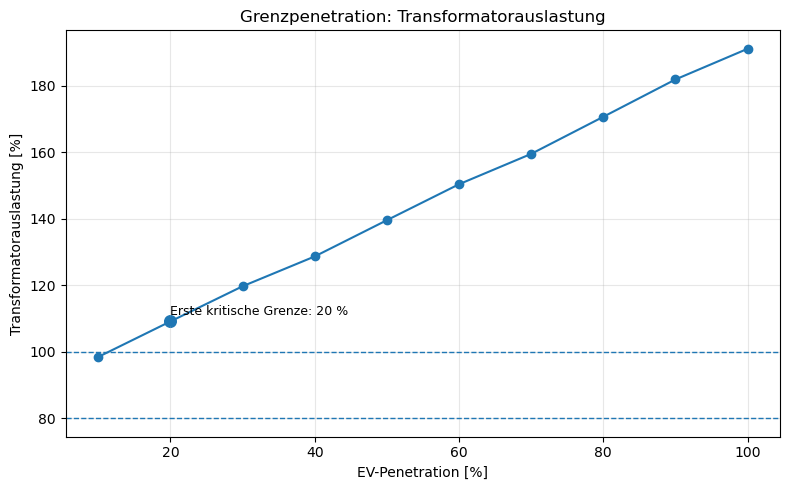

In [43]:
show_title("Visualisierung — Grenzpenetration (Transformatorauslastung)")

gp_plot_df = grenz_df.sort_values("penetration").copy()
gp_plot_df["penetration_percent"] = gp_plot_df["penetration"] * 100

plt.figure(figsize=(8, 5))
plt.plot(
    gp_plot_df["penetration_percent"],
    gp_plot_df["transformer_loading_percent"],
    marker="o"
)

plt.axhline(100, linestyle="--", linewidth=1)
plt.axhline(80, linestyle="--", linewidth=1)

if "first_critical" in locals():
    plt.scatter(
        [first_critical["penetration"] * 100],
        [first_critical["transformer_loading_percent"]],
        s=70
    )
    plt.text(
        first_critical["penetration"] * 100,
        first_critical["transformer_loading_percent"] + 2,
        f'Erste kritische Grenze: {int(first_critical["penetration"] * 100)} %',
        ha="left",
        fontsize=9
    )

plt.title("Grenzpenetration: Transformatorauslastung")
plt.xlabel("EV-Penetration [%]")
plt.ylabel("Transformatorauslastung [%]")
plt.grid(alpha=0.3)
plt.tight_layout()
export_figure("grenzpenetration_trafo_baseline.png")
plt.show()

## 7. Grenzpenetration mit Mitigation

Im folgenden Schritt wird die Grenzpenetrationsanalyse unter denselben Randbedingungen erneut durchgeführt, diesmal jedoch mit einer reduzierten Wallbox-Leistung von **7 kW**. Ziel ist es zu untersuchen, ob und in welchem Umfang die vereinfachte Mitigation die technische Aufnahmegrenze des Netzes verschiebt.

Anschließend werden die Ergebnisse der Grenzpenetration **ohne Mitigation** und **mit Mitigation** direkt miteinander verglichen.

In [44]:
penetration_steps_mit = [i / 100 for i in range(10, 101, 10)]

grenz_mit_config = {
    "gf": 0.60,
    "placement": "distributed",
    "wallbox_kw": 7
}

grenz_mit_rows = []

for penetration in penetration_steps_mit:
    scenario_name = f"GP_M_{int(penetration * 100)}"
    config = {
        "penetration": penetration,
        "gf": grenz_mit_config["gf"],
        "placement": grenz_mit_config["placement"],
        "wallbox_kw": grenz_mit_config["wallbox_kw"]
    }

    _, summary_row, _, _ = run_ev_scenario(base_net, scenario_name, config)
    grenz_mit_rows.append(summary_row)

grenz_mit_df = pd.DataFrame(grenz_mit_rows)

grenz_mit_display_df = grenz_mit_df.copy().rename(columns={
    "penetration": "EV-Anteil",
    "ev_count": "EV",
    "gf": "GF",
    "placement": "Platzierung",
    "wallbox_kw": "Wallbox [kW]",
    "total_ev_load_kw": "EV-Last [kW]",
    "transformer_loading_percent": "Trafo [%]",
    "max_line_loading_percent": "Max. Leitung [%]",
    "min_bus_voltage_pu": "Min. U [pu]",
    "status": "Bewertung"
})

grenz_mit_display_df["EV-Anteil"] = grenz_mit_display_df["EV-Anteil"].round(2)
grenz_mit_display_df["GF"] = grenz_mit_display_df["GF"].round(2)
grenz_mit_display_df["EV-Last [kW]"] = grenz_mit_display_df["EV-Last [kW]"].round(1)
grenz_mit_display_df["Trafo [%]"] = grenz_mit_display_df["Trafo [%]"].round(1)
grenz_mit_display_df["Max. Leitung [%]"] = grenz_mit_display_df["Max. Leitung [%]"].round(1)
grenz_mit_display_df["Min. U [pu]"] = grenz_mit_display_df["Min. U [pu]"].round(4)

grenz_mit_display_df["Platzierung"] = grenz_mit_display_df["Platzierung"].replace({
    "distributed": "verteilt",
    "remote_end": "Netzende"
})

grenz_mit_display_df["Bewertung"] = grenz_mit_display_df["Bewertung"].replace({
    "Critical": "Kritisch",
    "Warning": "Warnung",
    "OK": "Unkritisch"
})

grenz_mit_display_df = grenz_mit_display_df[
    ["EV-Anteil", "EV", "GF", "Platzierung", "Wallbox [kW]", "EV-Last [kW]",
     "Trafo [%]", "Max. Leitung [%]", "Min. U [pu]", "Bewertung"]
]

show_title("Ergebnisse der Grenzpenetrationsanalyse mit Mitigation")

show_table(
    grenz_mit_display_df,
    fmt={
        "EV-Anteil": "{:.2f}",
        "GF": "{:.2f}",
        "Wallbox [kW]": "{:.0f}",
        "EV-Last [kW]": "{:.1f}",
        "Trafo [%]": "{:.1f}",
        "Max. Leitung [%]": "{:.1f}",
        "Min. U [pu]": "{:.4f}"
    },
    text_cols=["Platzierung", "Bewertung"],
    numeric_cols=["EV-Anteil", "EV", "GF", "Wallbox [kW]", "EV-Last [kW]", "Trafo [%]", "Max. Leitung [%]", "Min. U [pu]"]
)

### Ergebnisse der Grenzpenetrationsanalyse mit Mitigation

EV-Anteil,EV,GF,Platzierung,Wallbox [kW],EV-Last [kW],Trafo [%],Max. Leitung [%],Min. U [pu],Bewertung
0.10,6,0.60,verteilt,7,25.2,94.7,56.9,0.9517,Unkritisch
0.20,12,0.60,verteilt,7,50.4,101.4,61.7,0.9464,Kritisch
0.30,18,0.60,verteilt,7,75.6,108.1,64.2,0.9450,Kritisch
0.40,23,0.60,verteilt,7,96.6,113.8,66.6,0.9422,Kritisch
0.50,29,0.60,verteilt,7,121.8,120.6,71.5,0.9369,Kritisch
0.60,35,0.60,verteilt,7,147.0,127.4,74.0,0.9354,Kritisch
0.70,40,0.60,verteilt,7,168.0,133.1,78.8,0.9324,Kritisch
0.80,46,0.60,verteilt,7,193.2,140.1,83.8,0.9268,Kritisch
0.90,52,0.60,verteilt,7,218.4,147.0,88.8,0.9220,Kritisch
1.00,57,0.60,verteilt,7,239.4,152.7,91.3,0.9202,Kritisch


In [45]:
critical_candidates_mit = grenz_mit_df[
    (grenz_mit_df["transformer_loading_percent"] > 100) |
    (grenz_mit_df["max_line_loading_percent"] > 100) |
    (grenz_mit_df["min_bus_voltage_pu"] < 0.90)
].copy()

if critical_candidates_mit.empty:
    show_title("Erste kritische Grenze mit Mitigation")
    display(Markdown("Es wurde im betrachteten Bereich keine kritische Netzverletzung festgestellt."))
else:
    first_critical_mit = critical_candidates_mit.sort_values("penetration").iloc[0]

    critical_reasons_mit = []

    if first_critical_mit["transformer_loading_percent"] > 100:
        critical_reasons_mit.append("Trafo > 100 %")
    if first_critical_mit["max_line_loading_percent"] > 100:
        critical_reasons_mit.append("Leitung > 100 %")
    if first_critical_mit["min_bus_voltage_pu"] < 0.90:
        critical_reasons_mit.append("U < 0,90 pu")

    first_critical_mit_df = pd.DataFrame([{
        "Erste kritische EV-Penetration": first_critical_mit["penetration"],
        "EV": int(first_critical_mit["ev_count"]),
        "GF": first_critical_mit["gf"],
        "Wallbox [kW]": first_critical_mit["wallbox_kw"],
        "EV-Last [kW]": first_critical_mit["total_ev_load_kw"],
        "Trafo [%]": first_critical_mit["transformer_loading_percent"],
        "Max. Leitung [%]": first_critical_mit["max_line_loading_percent"],
        "Min. U [pu]": first_critical_mit["min_bus_voltage_pu"],
        "Kritischer Auslöser": "; ".join(critical_reasons_mit)
    }])

    show_title("Erste kritische Grenze mit Mitigation")

    show_table(
        first_critical_mit_df,
        fmt={
            "Erste kritische EV-Penetration": "{:.2f}",
            "GF": "{:.2f}",
            "Wallbox [kW]": "{:.0f}",
            "EV-Last [kW]": "{:.1f}",
            "Trafo [%]": "{:.1f}",
            "Max. Leitung [%]": "{:.1f}",
            "Min. U [pu]": "{:.4f}"
        },
        text_cols=["Kritischer Auslöser"],
        numeric_cols=[
            "Erste kritische EV-Penetration", "EV", "GF", "Wallbox [kW]",
            "EV-Last [kW]", "Trafo [%]", "Max. Leitung [%]", "Min. U [pu]"
        ]
    )

### Erste kritische Grenze mit Mitigation

Erste kritische EV-Penetration,EV,GF,Wallbox [kW],EV-Last [kW],Trafo [%],Max. Leitung [%],Min. U [pu],Kritischer Auslöser
0.20,12,0.60,7,50.4,101.4,61.7,0.9464,Trafo > 100 %


In [46]:
grenz_compare_df = pd.DataFrame([
    {
        "Fall": "Ohne Mitigation",
        "Erste kritische EV-Penetration": first_critical["penetration"],
        "EV": int(first_critical["ev_count"]),
        "Wallbox [kW]": first_critical["wallbox_kw"],
        "EV-Last [kW]": first_critical["total_ev_load_kw"],
        "Trafo [%]": first_critical["transformer_loading_percent"],
        "Max. Leitung [%]": first_critical["max_line_loading_percent"],
        "Min. U [pu]": first_critical["min_bus_voltage_pu"]
    },
    {
        "Fall": "Mit Mitigation",
        "Erste kritische EV-Penetration": first_critical_mit["penetration"],
        "EV": int(first_critical_mit["ev_count"]),
        "Wallbox [kW]": first_critical_mit["wallbox_kw"],
        "EV-Last [kW]": first_critical_mit["total_ev_load_kw"],
        "Trafo [%]": first_critical_mit["transformer_loading_percent"],
        "Max. Leitung [%]": first_critical_mit["max_line_loading_percent"],
        "Min. U [pu]": first_critical_mit["min_bus_voltage_pu"]
    }
])

delta_compare_row = pd.DataFrame([{
    "Fall": "Δ Mitigation vs. ohne",
    "Erste kritische EV-Penetration": first_critical_mit["penetration"] - first_critical["penetration"],
    "EV": int(first_critical_mit["ev_count"] - first_critical["ev_count"]),
    "Wallbox [kW]": first_critical_mit["wallbox_kw"] - first_critical["wallbox_kw"],
    "EV-Last [kW]": first_critical_mit["total_ev_load_kw"] - first_critical["total_ev_load_kw"],
    "Trafo [%]": first_critical_mit["transformer_loading_percent"] - first_critical["transformer_loading_percent"],
    "Max. Leitung [%]": first_critical_mit["max_line_loading_percent"] - first_critical["max_line_loading_percent"],
    "Min. U [pu]": first_critical_mit["min_bus_voltage_pu"] - first_critical["min_bus_voltage_pu"]
}])

grenz_compare_with_delta_df = pd.concat(
    [grenz_compare_df, delta_compare_row],
    ignore_index=True
)

show_title("Vergleich der ersten kritischen Grenze")

show_table(
    grenz_compare_with_delta_df,
    fmt={
        "Erste kritische EV-Penetration": "{:.2f}",
        "Wallbox [kW]": "{:.0f}",
        "EV-Last [kW]": "{:.1f}",
        "Trafo [%]": "{:.1f}",
        "Max. Leitung [%]": "{:.1f}",
        "Min. U [pu]": "{:.4f}"
    },
    text_cols=["Fall"],
    numeric_cols=[
        "Erste kritische EV-Penetration", "EV", "Wallbox [kW]",
        "EV-Last [kW]", "Trafo [%]", "Max. Leitung [%]", "Min. U [pu]"
    ]
)

### Vergleich der ersten kritischen Grenze

Fall,Erste kritische EV-Penetration,EV,Wallbox [kW],EV-Last [kW],Trafo [%],Max. Leitung [%],Min. U [pu]
Ohne Mitigation,0.20,12,11,79.2,109.1,67.3,0.9414
Mit Mitigation,0.20,12,7,50.4,101.4,61.7,0.9464
Δ Mitigation vs. ohne,0.00,0,-4,-28.8,-7.7,-5.5,0.0050


In [47]:
fine_penetration_steps = [i / 100 for i in range(10, 31, 2)]

fine_rows = []

for penetration in fine_penetration_steps:
    scenario_name = f"GP_FINE_{int(penetration * 100)}"
    config = {
        "penetration": penetration,
        "gf": 0.60,
        "placement": "distributed",
        "wallbox_kw": 11
    }

    _, summary_row, _, _ = run_ev_scenario(base_net, scenario_name, config)
    fine_rows.append(summary_row)

fine_df = pd.DataFrame(fine_rows)

fine_display_df = fine_df.copy().rename(columns={
    "penetration": "EV-Anteil",
    "ev_count": "EV",
    "gf": "GF",
    "placement": "Platzierung",
    "wallbox_kw": "Wallbox [kW]",
    "total_ev_load_kw": "EV-Last [kW]",
    "transformer_loading_percent": "Trafo [%]",
    "max_line_loading_percent": "Max. Leitung [%]",
    "min_bus_voltage_pu": "Min. U [pu]",
    "status": "Bewertung"
})

fine_display_df["Platzierung"] = fine_display_df["Platzierung"].replace({
    "distributed": "verteilt"
})

fine_display_df["Bewertung"] = fine_display_df["Bewertung"].replace({
    "Critical": "Kritisch",
    "Warning": "Warnung",
    "OK": "Unkritisch"
})

fine_display_df = fine_display_df[
    ["EV-Anteil", "EV", "GF", "Platzierung", "Wallbox [kW]", "EV-Last [kW]",
     "Trafo [%]", "Max. Leitung [%]", "Min. U [pu]", "Bewertung"]
]

show_title("Feinauflösung der Grenzpenetration ohne Mitigation")

show_table(
    fine_display_df,
    fmt={
        "EV-Anteil": "{:.2f}",
        "GF": "{:.2f}",
        "Wallbox [kW]": "{:.0f}",
        "EV-Last [kW]": "{:.1f}",
        "Trafo [%]": "{:.1f}",
        "Max. Leitung [%]": "{:.1f}",
        "Min. U [pu]": "{:.4f}"
    },
    text_cols=["Platzierung", "Bewertung"],
    numeric_cols=["EV-Anteil", "EV", "GF", "Wallbox [kW]", "EV-Last [kW]", "Trafo [%]", "Max. Leitung [%]", "Min. U [pu]"]
)

### Feinauflösung der Grenzpenetration ohne Mitigation

EV-Anteil,EV,GF,Platzierung,Wallbox [kW],EV-Last [kW],Trafo [%],Max. Leitung [%],Min. U [pu],Bewertung
0.10,6,0.60,verteilt,11,39.6,98.5,59.6,0.9499,Warnung
0.12,7,0.60,verteilt,11,46.2,100.4,59.8,0.9471,Kritisch
0.14,8,0.60,verteilt,11,52.8,102.1,59.7,0.9488,Kritisch
0.16,10,0.60,verteilt,11,66.0,105.6,59.8,0.9480,Kritisch
0.18,11,0.60,verteilt,11,72.6,107.3,63.5,0.9451,Kritisch
0.20,12,0.60,verteilt,11,79.2,109.1,67.3,0.9414,Kritisch
0.22,13,0.60,verteilt,11,85.8,110.9,63.6,0.9444,Kritisch
0.24,14,0.60,verteilt,11,92.4,112.8,67.3,0.9414,Kritisch
0.26,15,0.60,verteilt,11,99.0,114.4,67.2,0.9430,Kritisch
0.28,16,0.60,verteilt,11,105.6,116.2,67.4,0.9406,Kritisch


In [48]:
fine_penetration_steps_mit = [i / 100 for i in range(10, 31, 2)]

fine_mit_rows = []

for penetration in fine_penetration_steps_mit:
    scenario_name = f"GP_FINE_M_{int(penetration * 100)}"
    config = {
        "penetration": penetration,
        "gf": 0.60,
        "placement": "distributed",
        "wallbox_kw": 7
    }

    _, summary_row, _, _ = run_ev_scenario(base_net, scenario_name, config)
    fine_mit_rows.append(summary_row)

fine_mit_df = pd.DataFrame(fine_mit_rows)

fine_mit_display_df = fine_mit_df.copy().rename(columns={
    "penetration": "EV-Anteil",
    "ev_count": "EV",
    "gf": "GF",
    "placement": "Platzierung",
    "wallbox_kw": "Wallbox [kW]",
    "total_ev_load_kw": "EV-Last [kW]",
    "transformer_loading_percent": "Trafo [%]",
    "max_line_loading_percent": "Max. Leitung [%]",
    "min_bus_voltage_pu": "Min. U [pu]",
    "status": "Bewertung"
})

fine_mit_display_df["Platzierung"] = fine_mit_display_df["Platzierung"].replace({
    "distributed": "verteilt"
})

fine_mit_display_df["Bewertung"] = fine_mit_display_df["Bewertung"].replace({
    "Critical": "Kritisch",
    "Warning": "Warnung",
    "OK": "Unkritisch"
})

fine_mit_display_df = fine_mit_display_df[
    ["EV-Anteil", "EV", "GF", "Platzierung", "Wallbox [kW]", "EV-Last [kW]",
     "Trafo [%]", "Max. Leitung [%]", "Min. U [pu]", "Bewertung"]
]

show_title("Feinauflösung der Grenzpenetration mit Mitigation")

show_table(
    fine_mit_display_df,
    fmt={
        "EV-Anteil": "{:.2f}",
        "GF": "{:.2f}",
        "Wallbox [kW]": "{:.0f}",
        "EV-Last [kW]": "{:.1f}",
        "Trafo [%]": "{:.1f}",
        "Max. Leitung [%]": "{:.1f}",
        "Min. U [pu]": "{:.4f}"
    },
    text_cols=["Platzierung", "Bewertung"],
    numeric_cols=["EV-Anteil", "EV", "GF", "Wallbox [kW]", "EV-Last [kW]", "Trafo [%]", "Max. Leitung [%]", "Min. U [pu]"]
)

### Feinauflösung der Grenzpenetration mit Mitigation

EV-Anteil,EV,GF,Platzierung,Wallbox [kW],EV-Last [kW],Trafo [%],Max. Leitung [%],Min. U [pu],Bewertung
0.10,6,0.60,verteilt,7,25.2,94.7,56.9,0.9517,Unkritisch
0.12,7,0.60,verteilt,7,29.4,95.9,57.0,0.9500,Unkritisch
0.14,8,0.60,verteilt,7,33.6,96.9,57.0,0.9510,Unkritisch
0.16,10,0.60,verteilt,7,42.0,99.2,57.0,0.9505,Unkritisch
0.18,11,0.60,verteilt,7,46.2,100.3,59.4,0.9488,Kritisch
0.20,12,0.60,verteilt,7,50.4,101.4,61.7,0.9464,Kritisch
0.22,13,0.60,verteilt,7,54.6,102.6,59.4,0.9483,Kritisch
0.24,14,0.60,verteilt,7,58.8,103.7,61.8,0.9464,Kritisch
0.26,15,0.60,verteilt,7,63.0,104.8,61.7,0.9474,Kritisch
0.28,16,0.60,verteilt,7,67.2,105.9,61.8,0.9459,Kritisch


In [49]:
fine_critical_ohne = fine_df[
    (fine_df["transformer_loading_percent"] > 100) |
    (fine_df["max_line_loading_percent"] > 100) |
    (fine_df["min_bus_voltage_pu"] < 0.90)
].sort_values("penetration").iloc[0]

fine_critical_mit = fine_mit_df[
    (fine_mit_df["transformer_loading_percent"] > 100) |
    (fine_mit_df["max_line_loading_percent"] > 100) |
    (fine_mit_df["min_bus_voltage_pu"] < 0.90)
].sort_values("penetration").iloc[0]

fine_compare_df = pd.DataFrame([
    {
        "Fall": "Ohne Mitigation",
        "Erste kritische EV-Penetration": fine_critical_ohne["penetration"],
        "EV": int(fine_critical_ohne["ev_count"]),
        "Wallbox [kW]": fine_critical_ohne["wallbox_kw"]
    },
    {
        "Fall": "Mit Mitigation",
        "Erste kritische EV-Penetration": fine_critical_mit["penetration"],
        "EV": int(fine_critical_mit["ev_count"]),
        "Wallbox [kW]": fine_critical_mit["wallbox_kw"]
    },
    {
        "Fall": "Δ Mitigation vs. ohne",
        "Erste kritische EV-Penetration": fine_critical_mit["penetration"] - fine_critical_ohne["penetration"],
        "EV": int(fine_critical_mit["ev_count"] - fine_critical_ohne["ev_count"]),
        "Wallbox [kW]": fine_critical_mit["wallbox_kw"] - fine_critical_ohne["wallbox_kw"]
    }
])

show_title("Vergleich der feinaufgelösten kritischen Grenze")

show_table(
    fine_compare_df,
    fmt={
        "Erste kritische EV-Penetration": "{:.2f}",
        "Wallbox [kW]": "{:.0f}"
    },
    text_cols=["Fall"],
    numeric_cols=["Erste kritische EV-Penetration", "EV", "Wallbox [kW]"]
)

### Vergleich der feinaufgelösten kritischen Grenze

Fall,Erste kritische EV-Penetration,EV,Wallbox [kW]
Ohne Mitigation,0.12,7,11
Mit Mitigation,0.18,11,7
Δ Mitigation vs. ohne,0.06,4,-4


### Technische Interpretation — Wirkung der Mitigation auf die Grenzpenetration

Die feinaufgelöste Analyse zeigt, dass die erste kritische EV-Penetration ohne Mitigation bereits bei **12 %** beginnt. Mit der vereinfachten Mitigation in Form einer reduzierten Wallbox-Leistung von **7 kW** verschiebt sich diese Grenze auf **18 %**.

Damit wird deutlich, dass die Mitigation nicht nur die Netzbelastung im Stressfall reduziert, sondern auch die technische Aufnahmegrenze des betrachteten Niederspannungsnetzes erhöht. Der Effekt ist damit aus Netzsicht relevant, auch wenn die Mitigation die kritische Grenze nicht vollständig aufhebt, sondern lediglich in einen höheren Bereich verschiebt.

In [50]:

_ = export_table(scenario_summary_display_df, "scenario_summary.csv")
_ = export_table(critical_elements_display_df, "critical_elements.csv")
_ = export_table(mitigation_compare_with_delta_df, "mitigation_comparison.csv")
_ = export_table(grenz_display_df, "grenzpenetration_baseline.csv")
_ = export_table(grenz_mit_display_df, "grenzpenetration_mitigation.csv")
_ = export_table(fine_compare_df, "grenzpenetration_fine_comparison.csv")

## 8. Visualisierungen

Die folgenden Abbildungen zeigen die zentralen Auswirkungen der EV-Szenarien auf Transformator, Leitungen und Spannungsprofil. Ergänzend werden die Ergebnisse jeweils kurz technisch eingeordnet.

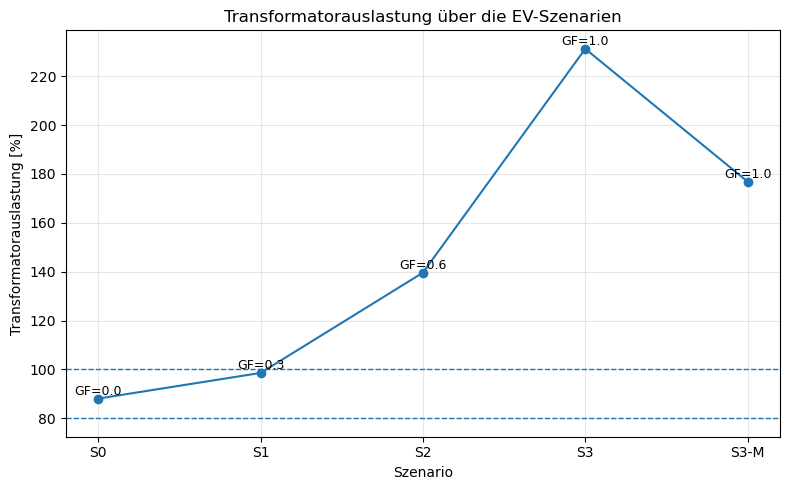

### Visualisierung — Transformatorauslastung

Szenario,GF [-],Transformatorauslastung [%]
S0 — Referenzfall,0.00,88.0
S1 — Moderate EV-Integration,0.30,98.6
S2 — Erhöhte EV-Integration,0.60,139.6
S3 — Stressfall,1.00,231.2
S3 — Mitigation (7 kW),1.00,176.8


In [51]:
df = scenario_summary_df.copy()

scenario_col = next((c for c in df.columns if "scenario" in c.lower()), None)
gf_col = next((c for c in df.columns if c.lower() in ["gf", "gleichzeitigkeitsfaktor"] or "gleich" in c.lower()), None)
trafo_col = next((c for c in df.columns if ("trafo" in c.lower() or "transform" in c.lower()) and ("load" in c.lower() or "auslast" in c.lower())), None)

if not all([scenario_col, gf_col, trafo_col]):
    print("Gefundene Spalten:", list(df.columns))
    raise ValueError("Erforderliche Spalten konnten nicht automatisch erkannt werden. Bitte die Spaltennamen prüfen.")

plot_df = pd.DataFrame({
    "scenario": df[scenario_col].astype(str),
    "gf": df[gf_col],
    "transformer_loading_percent": df[trafo_col]
})

scenario_order_map = {
    "S0_Base": 0,
    "S1_Moderate": 1,
    "S2_Elevated": 2,
    "S3_Stress": 3,
    "S3_Mitigation": 4
}

scenario_short_map = {
    "S0_Base": "S0",
    "S1_Moderate": "S1",
    "S2_Elevated": "S2",
    "S3_Stress": "S3",
    "S3_Mitigation": "S3-M"
}

plot_df["scenario_order"] = plot_df["scenario"].map(scenario_order_map)
plot_df = plot_df.sort_values("scenario_order").reset_index(drop=True)
plot_df["scenario_short"] = plot_df["scenario"].map(scenario_short_map)
plot_df["scenario_label"] = plot_df["scenario"].replace(scenario_label_map)

plt.figure(figsize=(8, 5))
plt.plot(plot_df["scenario_short"], plot_df["transformer_loading_percent"], marker="o")

for _, row in plot_df.iterrows():
    plt.text(
        row["scenario_short"],
        row["transformer_loading_percent"] + 1.5,
        f"GF={row['gf']}",
        ha="center",
        fontsize=9
    )

plt.axhline(80, linestyle="--", linewidth=1)
plt.axhline(100, linestyle="--", linewidth=1)

plt.title("Transformatorauslastung über die EV-Szenarien")
plt.xlabel("Szenario")
plt.ylabel("Transformatorauslastung [%]")
plt.grid(alpha=0.3)
plt.tight_layout()
export_figure("transformatorauslastung_szenarien.png")
plt.show()

plot_display_df = plot_df[["scenario_label", "gf", "transformer_loading_percent"]].rename(columns={
    "scenario_label": "Szenario",
    "gf": "GF [-]",
    "transformer_loading_percent": "Transformatorauslastung [%]"
})

plot_display_df["GF [-]"] = plot_display_df["GF [-]"].round(2)
plot_display_df["Transformatorauslastung [%]"] = plot_display_df["Transformatorauslastung [%]"].round(1)

show_title("Visualisierung — Transformatorauslastung")

show_table(
    plot_display_df,
    fmt={
        "GF [-]": "{:.2f}",
        "Transformatorauslastung [%]": "{:.1f}"
    },
    text_cols=["Szenario"],
    numeric_cols=["GF [-]", "Transformatorauslastung [%]"]
)

### Technische Interpretation — Transformatorauslastung

Die Transformatorauslastung steigt mit zunehmender EV-Integration deutlich an. Bereits der Referenzfall liegt im verwendeten Testnetz bei einem vergleichsweise hohen Ausgangsniveau. Mit zusätzlicher EV-Last nimmt die Auslastung jedoch nochmals klar zu, sodass der Transformator in den höheren Szenarien zum dominierenden Engpass wird.

Wichtig für die Einordnung ist: Das verwendete Kerber-Dorfnetz ist ein **repräsentatives pandapower-Testnetz** und kein real kalibriertes Netz eines konkreten Netzbetreibers. Der Fokus der Analyse liegt daher nicht auf der absoluten Plausibilisierung eines einzelnen Startwerts, sondern auf der **relativen Veränderung** zwischen Referenzfall, EV-Szenarien, Mitigation und Grenzpenetration.

Aus technischer Sicht zeigt das Ergebnis dennoch klar, dass der Transformator im betrachteten Netz die maßgebende Restriktion darstellt. Mit steigender EV-Penetration wird die Transformatorauslastung früher kritisch als die meisten übrigen Kennwerte und prägt damit die technische Aufnahmegrenze wesentlich.

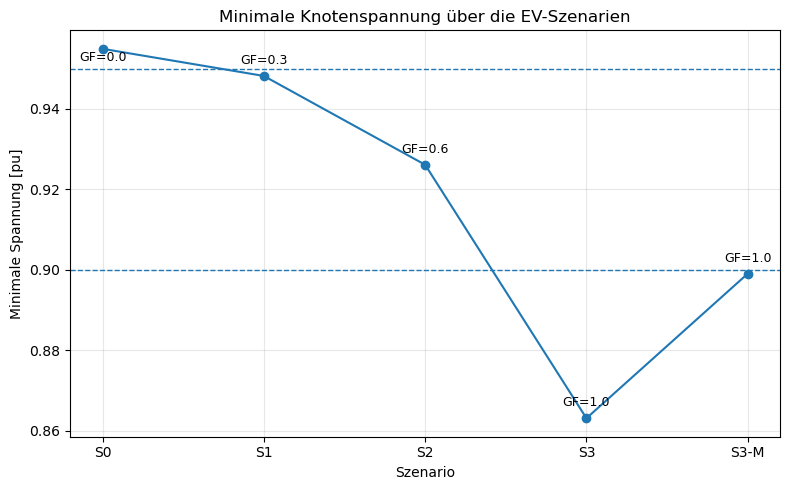

### Visualisierung — Minimale Knotenspannung

Szenario,GF [-],Minimale Spannung [pu]
S0 — Referenzfall,0.00,0.9550
S1 — Moderate EV-Integration,0.30,0.9482
S2 — Erhöhte EV-Integration,0.60,0.9261
S3 — Stressfall,1.00,0.8631
S3 — Mitigation (7 kW),1.00,0.8990


In [52]:
df = scenario_summary_df.copy()

scenario_col = next((c for c in df.columns if "scenario" in c.lower()), None)
gf_col = next((c for c in df.columns if c.lower() in ["gf", "gleichzeitigkeitsfaktor"] or "gleich" in c.lower()), None)
voltage_col = next((c for c in df.columns if ("min" in c.lower()) and ("voltage" in c.lower() or "vm" in c.lower())), None)

if not all([scenario_col, gf_col, voltage_col]):
    print("Gefundene Spalten:", list(df.columns))
    raise ValueError("Erforderliche Spalten konnten nicht automatisch erkannt werden. Bitte die Spaltennamen prüfen.")

plot_df = pd.DataFrame({
    "scenario": df[scenario_col].astype(str),
    "gf": df[gf_col],
    "min_bus_voltage_pu": df[voltage_col]
})

scenario_order_map = {
    "S0_Base": 0,
    "S1_Moderate": 1,
    "S2_Elevated": 2,
    "S3_Stress": 3,
    "S3_Mitigation": 4
}

scenario_short_map = {
    "S0_Base": "S0",
    "S1_Moderate": "S1",
    "S2_Elevated": "S2",
    "S3_Stress": "S3",
    "S3_Mitigation": "S3-M"
}

plot_df["scenario_order"] = plot_df["scenario"].map(scenario_order_map)
plot_df = plot_df.sort_values("scenario_order").reset_index(drop=True)
plot_df["scenario_short"] = plot_df["scenario"].map(scenario_short_map)
plot_df["scenario_label"] = plot_df["scenario"].replace(scenario_label_map)

plt.figure(figsize=(8, 5))
plt.plot(plot_df["scenario_short"], plot_df["min_bus_voltage_pu"], marker="o")

for _, row in plot_df.iterrows():
    y_offset = -0.003 if row["scenario_short"] == "S0" else 0.003
    plt.text(
        row["scenario_short"],
        row["min_bus_voltage_pu"] + y_offset,
        f"GF={row['gf']}",
        ha="center",
        fontsize=9
    )

plt.axhline(0.95, linestyle="--", linewidth=1)
plt.axhline(0.90, linestyle="--", linewidth=1)

plt.title("Minimale Knotenspannung über die EV-Szenarien")
plt.xlabel("Szenario")
plt.ylabel("Minimale Spannung [pu]")
plt.grid(alpha=0.3)
plt.tight_layout()
export_figure("minimale_knotenspannung_szenarien.png")
plt.show()

plot_display_df = plot_df[["scenario_label", "gf", "min_bus_voltage_pu"]].rename(columns={
    "scenario_label": "Szenario",
    "gf": "GF [-]",
    "min_bus_voltage_pu": "Minimale Spannung [pu]"
})

plot_display_df["GF [-]"] = plot_display_df["GF [-]"].round(2)
plot_display_df["Minimale Spannung [pu]"] = plot_display_df["Minimale Spannung [pu]"].round(4)

show_title("Visualisierung — Minimale Knotenspannung")

show_table(
    plot_display_df,
    fmt={
        "GF [-]": "{:.2f}",
        "Minimale Spannung [pu]": "{:.4f}"
    },
    text_cols=["Szenario"],
    numeric_cols=["GF [-]", "Minimale Spannung [pu]"]
)

### Technische Interpretation — Minimale Knotenspannung

Die Ergebnisse zeigen, dass die minimale Knotenspannung mit wachsender EV-Durchdringung kontinuierlich abnimmt. Bereits in S1 wird die praktische Bewertungsgrenze leicht unterschritten. In S2 verstärkt sich die Spannungsabsenkung deutlich, und im Stressfall treten klar kritische Spannungswerte auf.

Damit wird erkennbar, dass nicht nur die Betriebsmittelauslastung, sondern auch die Spannungshaltung zu einem begrenzenden Faktor der EV-Integration wird. Besonders kritisch sind dabei Netzknoten in größerer elektrischer Entfernung zum Transformator.

### Visualisierung — Leitungsauslastung

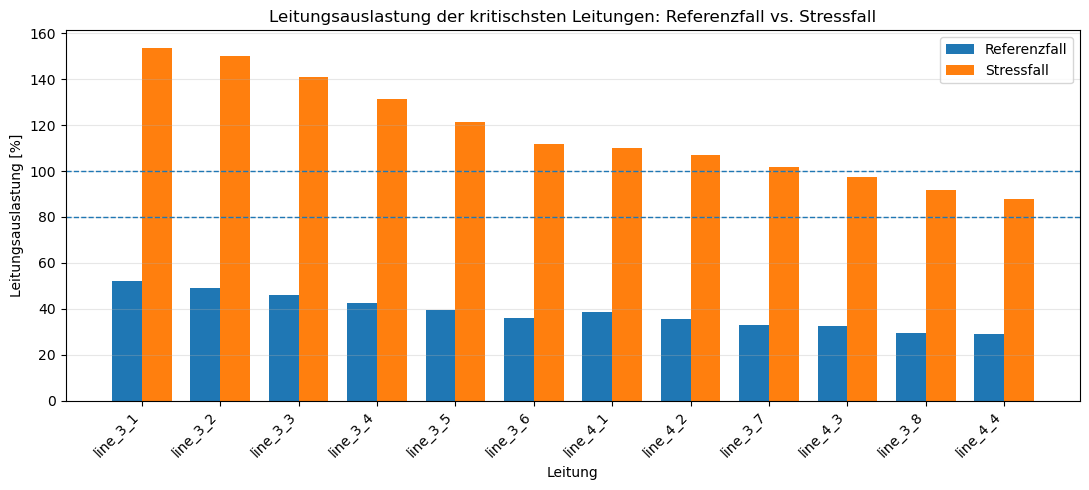

### Maßgebende Leitungen nach Zunahme der Auslastung

line_index,Leitung,Referenzfall [%],Stressfall [%],Differenz [%-Pkt.]
36,line_3_1,52.2,153.6,101.4
38,line_3_2,49.0,150.3,101.3
40,line_3_3,45.8,140.8,95.0
42,line_3_4,42.6,131.2,88.7
44,line_3_5,39.3,121.5,82.2
46,line_3_6,36.1,111.8,75.7
68,line_4_1,38.8,110.2,71.4
70,line_4_2,35.6,106.9,71.3
48,line_3_7,32.8,101.9,69.1
72,line_4_3,32.4,97.5,65.1


In [53]:
# Referenz- und Stressfall festlegen
base_case_key = "S0_Base"
stress_case_key = "S3_Stress"

if base_case_key not in scenario_nets or stress_case_key not in scenario_nets:
    raise ValueError("Die erforderlichen Szenarien S0_Base und S3_Stress wurden nicht gefunden.")

base_net_sc = scenario_nets[base_case_key]
stress_net_sc = scenario_nets[stress_case_key]

# Vergleichstabelle aufbauen
compare_df = pd.DataFrame({
    "line_index": base_net_sc.res_line.index,
    "line_name": base_net_sc.line["name"].values,
    "base_loading_percent": base_net_sc.res_line["loading_percent"].values,
    "stress_loading_percent": stress_net_sc.res_line["loading_percent"].values
})

compare_df["delta_loading_percent"] = (
    compare_df["stress_loading_percent"] - compare_df["base_loading_percent"]
)

# Für die Darstellung: kritischste Leitungen nach Zunahme auswählen
top_n = 12
top_compare_df = (
    compare_df.sort_values("delta_loading_percent", ascending=False)
    .head(top_n)
    .sort_values("stress_loading_percent", ascending=False)
    .reset_index(drop=True)
)

# Kompakte deutsche Anzeigetabelle
compare_display_df = top_compare_df.rename(columns={
    "line_name": "Leitung",
    "base_loading_percent": "Referenzfall [%]",
    "stress_loading_percent": "Stressfall [%]",
    "delta_loading_percent": "Differenz [%-Pkt.]"
})

compare_display_df["Referenzfall [%]"] = compare_display_df["Referenzfall [%]"].round(1)
compare_display_df["Stressfall [%]"] = compare_display_df["Stressfall [%]"].round(1)
compare_display_df["Differenz [%-Pkt.]"] = compare_display_df["Differenz [%-Pkt.]"].round(1)

compare_display_df["Leitung"] = compare_display_df["Leitung"].fillna(
    "Leitung_" + top_compare_df["line_index"].astype(str)
)

# Bar-Chart
show_title("Visualisierung — Leitungsauslastung")
x = range(len(compare_display_df))
width = 0.38

plt.figure(figsize=(11, 5))
plt.bar(
    [i - width/2 for i in x],
    compare_display_df["Referenzfall [%]"],
    width=width,
    label="Referenzfall"
)
plt.bar(
    [i + width/2 for i in x],
    compare_display_df["Stressfall [%]"],
    width=width,
    label="Stressfall"
)

plt.axhline(80, linestyle="--", linewidth=1)
plt.axhline(100, linestyle="--", linewidth=1)

plt.xticks(x, compare_display_df["Leitung"], rotation=45, ha="right")
plt.title("Leitungsauslastung der kritischsten Leitungen: Referenzfall vs. Stressfall")
plt.xlabel("Leitung")
plt.ylabel("Leitungsauslastung [%]")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
export_figure("leitungsauslastung_ref_vs_stress.png")
plt.show()


show_title("Maßgebende Leitungen nach Zunahme der Auslastung")

show_table(
    compare_display_df,
    fmt={
        "Referenzfall [%]": "{:.1f}",
        "Stressfall [%]": "{:.1f}",
        "Differenz [%-Pkt.]": "{:.1f}"
    },
    text_cols=["Leitung"],
    numeric_cols=["Referenzfall [%]", "Stressfall [%]", "Differenz [%-Pkt.]"]
)

In [54]:
# Kompakte Top-5-Tabelle: kritischste Leitungen im Stressfall
top5_lines_df = (
    compare_df
    .sort_values(
        ["stress_loading_percent", "delta_loading_percent"],
        ascending=[False, False]
    )
    .head(5)
    .reset_index(drop=True)
    .copy()
)

top5_lines_df["Leitung"] = top5_lines_df["line_name"].fillna(
    "Leitung_" + top5_lines_df["line_index"].astype(str)
)

top5_lines_display_df = pd.DataFrame({
    "Rang": range(1, len(top5_lines_df) + 1),
    "Leitung": top5_lines_df["Leitung"],
    "Referenzfall [%]": top5_lines_df["base_loading_percent"].round(1),
    "Stressfall [%]": top5_lines_df["stress_loading_percent"].round(1),
    "Differenz [%-Pkt.]": top5_lines_df["delta_loading_percent"].round(1),
    "Kritisch (>100 %)": np.where(top5_lines_df["stress_loading_percent"] > 100, "Ja", "Nein")
})

show_title("Top-5 kritischste Leitungen im Stressfall")

show_table(
    top5_lines_display_df,
    fmt={
        "Referenzfall [%]": "{:.1f}",
        "Stressfall [%]": "{:.1f}",
        "Differenz [%-Pkt.]": "{:.1f}"
    },
    text_cols=["Leitung", "Kritisch (>100 %)"],
    numeric_cols=["Rang", "Referenzfall [%]", "Stressfall [%]", "Differenz [%-Pkt.]"]
)

top5_lines_display_df.to_csv(
    "../results/tables/top5_kritische_leitungen_stressfall.csv",
    index=False,
    encoding="utf-8-sig"
)

### Top-5 kritischste Leitungen im Stressfall

Rang,Leitung,Referenzfall [%],Stressfall [%],Differenz [%-Pkt.],Kritisch (>100 %)
1,line_3_1,52.2,153.6,101.4,Ja
2,line_3_2,49.0,150.3,101.3,Ja
3,line_3_3,45.8,140.8,95.0,Ja
4,line_3_4,42.6,131.2,88.7,Ja
5,line_3_5,39.3,121.5,82.2,Ja


### Technische Interpretation — kritischste Leitungsabschnitte im Stressfall

Die Top-5-Tabelle zeigt, dass im Stressfall mehrere Leitungsabschnitte deutlich über die 100-%-Grenze ansteigen. Während diese Leitungen im Referenzfall noch im unkritischen bis moderaten Bereich liegen, treten unter hoher EV-Integration ausgeprägte Zusatzbelastungen auf.

Auffällig ist, dass die kritischsten Leitungen nicht nur hohe absolute Auslastungen, sondern auch starke Zuwächse gegenüber dem Referenzfall aufweisen. Damit wird deutlich, dass im betrachteten Netz nicht ausschließlich der Transformator maßgebend ist, sondern im Stressfall auch einzelne Leitungsabschnitte zu lokalen Engpässen werden können.

Aus Netzsicht spricht dies dafür, bei hoher EV-Durchdringung nicht nur die Transformatorreserve, sondern auch die belasteten Leitungsabschnitte gezielt in die technische Bewertung einzubeziehen.

### Visualisierung — Spannungsprofil

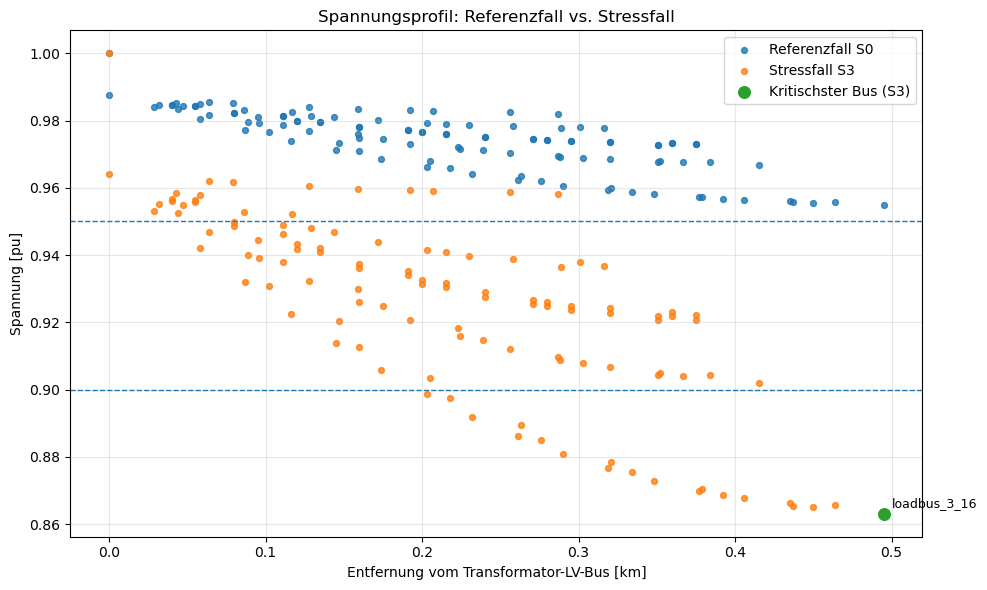

### Kritischste Busse im Spannungsprofil

Busindex,Busname,Entfernung [km],Referenzfall S0 [pu],Stressfall S3 [pu]
69,loadbus_3_16,0.495,0.9550,0.8631
67,loadbus_3_15,0.450,0.9556,0.8651
65,loadbus_3_14,0.437,0.9557,0.8653
68,KV_3_16,0.464,0.9558,0.8655
66,MUF_3_15,0.435,0.9560,0.8663
64,KV_3_14,0.406,0.9565,0.8677
63,loadbus_3_13,0.392,0.9568,0.8688
62,MUF_3_13,0.377,0.9572,0.8699
61,loadbus_3_12,0.379,0.9573,0.8705
60,KV_3_12,0.348,0.9581,0.8729


In [55]:
# Referenz- und Stressfall laden
base_case = scenario_nets["S0_Base"]
stress_case = scenario_nets["S3_Stress"]

# LV-Seite des Transformators
lv_bus = int(base_case.trafo.lv_bus.iloc[0])

# Elektrische Distanz vom Transformator-LV-Bus
distance_to_lv = top.calc_distance_to_bus(base_case, lv_bus)

# Fallback-Namen für fehlende Busnamen
fallback_bus_names = pd.Series(
    [f"bus_{idx}" for idx in base_case.bus.index],
    index=base_case.bus.index
)

bus_names = base_case.bus["name"].copy()
bus_names = bus_names.where(bus_names.notna(), fallback_bus_names)

# Vergleichstabelle
voltage_profile_df = pd.DataFrame({
    "bus_index": base_case.bus.index,
    "bus_name": bus_names,
    "distance_km": distance_to_lv.reindex(base_case.bus.index),
    "base_vm_pu": base_case.res_bus.vm_pu.reindex(base_case.bus.index),
    "stress_vm_pu": stress_case.res_bus.vm_pu.reindex(base_case.bus.index)
})

# Nur erreichbare Busse behalten
plot_df = (
    voltage_profile_df
    .dropna(subset=["distance_km"])
    .sort_values(["distance_km", "bus_index"])
    .reset_index(drop=True)
)

# Kritischste Spannung im Stressfall
weakest_bus = plot_df.loc[plot_df["stress_vm_pu"].idxmin()]

# Grafik
show_title("Visualisierung — Spannungsprofil")
plt.figure(figsize=(10, 6))

plt.scatter(
    plot_df["distance_km"],
    plot_df["base_vm_pu"],
    s=18,
    alpha=0.8,
    label="Referenzfall S0"
)

plt.scatter(
    plot_df["distance_km"],
    plot_df["stress_vm_pu"],
    s=18,
    alpha=0.8,
    label="Stressfall S3"
)

plt.axhline(0.95, linestyle="--", linewidth=1)
plt.axhline(0.90, linestyle="--", linewidth=1)

plt.scatter(
    [weakest_bus["distance_km"]],
    [weakest_bus["stress_vm_pu"]],
    s=70,
    label="Kritischster Bus (S3)"
)

plt.text(
    weakest_bus["distance_km"] + 0.005,
    weakest_bus["stress_vm_pu"] + 0.002,
    f"{weakest_bus['bus_name']}",
    ha="left",
    fontsize=9
)

plt.title("Spannungsprofil: Referenzfall vs. Stressfall")
plt.xlabel("Entfernung vom Transformator-LV-Bus [km]")
plt.ylabel("Spannung [pu]")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
export_figure("spannungsprofil_ref_vs_stress.png")
plt.show()

# Kontrolltabelle: niedrigste Spannungen im Stressfall
profile_display_df = (
    plot_df.sort_values("stress_vm_pu")
    .head(10)
    .rename(columns={
        "bus_index": "Busindex",
        "bus_name": "Busname",
        "distance_km": "Entfernung [km]",
        "base_vm_pu": "Referenzfall S0 [pu]",
        "stress_vm_pu": "Stressfall S3 [pu]"
    })
)

show_title("Kritischste Busse im Spannungsprofil")

show_table(
    profile_display_df[[
        "Busindex", "Busname", "Entfernung [km]",
        "Referenzfall S0 [pu]", "Stressfall S3 [pu]"
    ]],
    fmt={
        "Entfernung [km]": "{:.3f}",
        "Referenzfall S0 [pu]": "{:.4f}",
        "Stressfall S3 [pu]": "{:.4f}"
    },
    text_cols=["Busname"],
    numeric_cols=["Busindex", "Entfernung [km]", "Referenzfall S0 [pu]", "Stressfall S3 [pu]"]
)

### Technische Interpretation — Spannungsprofil im LV-Netz

Das Spannungsprofil zeigt, dass die Spannungen mit zunehmender Entfernung vom Transformator tendenziell abnehmen. Im Referenzfall bleibt dieser Verlauf noch weitgehend im unkritischen Bereich. Im Stressfall verstärkt sich der Spannungsabfall jedoch deutlich, insbesondere an weiter entfernten Netzknoten.

Die niedrigsten Spannungen treten erwartungsgemäß am Netzausläufer auf. Dies weist darauf hin, dass bei hoher EV-Durchdringung die Spannungshaltung in entfernten Bereichen des Niederspannungsnetzes zu einem kritischen Faktor wird.

## 9. Grenzen der Analyse

Dieses Projekt basiert auf einem repräsentativen Niederspannungsnetz aus pandapower
und nicht auf realen Netzdaten eines konkreten Netzbetreibers. Die Ergebnisse sind
daher als technisch plausible Szenarioanalyse zu verstehen, nicht als standortspezifische
Planungsaussage.

Zusätzlich wurden vereinfachende Annahmen für die EV-Integration getroffen. Dazu
gehören insbesondere eine feste Wallbox-Leistung, definierte Gleichzeitigkeitsfaktoren
sowie eine vereinfachte Platzierung der zusätzlichen Ladepunkte an ausgewählten
Lastknoten.

Die Bewertung orientiert sich an praxisnahen technischen Schwellenwerten für
Transformatorauslastung, Leitungsauslastung und Spannungsniveau. Diese Einordnung
dient der transparenten Interpretation der Ergebnisse, ersetzt jedoch keine formale
Netzberechnung oder einen verbindlichen Nachweis nach den Vorgaben eines
konkreten Netzbetreibers.

Nicht betrachtet wurden in dieser ersten Projektversion unter anderem Zeitreihen,
dynamische Lastverläufe, Smart-Charging-Strategien, wirtschaftliche Bewertungen
oder reale Anschlussdaten. Der Fokus liegt bewusst auf einer klaren, nachvollziehbaren
und reproduzierbaren Erstbewertung des Netzeinflusses zusätzlicher EV-Ladeleistungen.

## 10. Fazit und nächste Schritte

Die Analyse zeigt, dass zusätzliche EV-Ladeleistungen in einem typischen Niederspannungsnetz zu einer deutlich erhöhten technischen Beanspruchung führen können. Mit steigender EV-Penetration nehmen insbesondere die Transformatorauslastung und die Spannungsprobleme sichtbar zu. Der Transformator erweist sich im betrachteten Netz als dominierender Engpass.

Darüber hinaus zeigt der vereinfachte Mitigationstest, dass eine Reduktion der Wallbox-Leistung von **11 kW auf 7 kW** die Netzbelastung im Stressfall spürbar verringert. Die Maßnahme löst den stark belasteten Stressfall zwar nicht vollständig, verbessert jedoch die maßgebenden technischen Kennwerte.

Besonders relevant ist das Ergebnis der Grenzpenetrationsanalyse:  
Die erste kritische EV-Penetration liegt unter den gewählten Annahmen **ohne Mitigation bei etwa 12 %** und **mit Mitigation bei etwa 18 %**. Damit zeigt das Projekt nicht nur eine reine Belastungsanalyse, sondern auch, dass eine einfache netzorientierte Leistungsbegrenzung die technische Aufnahmegrenze des Netzes erhöhen kann.

Als nächster fachlicher Ausbauschritt wäre beispielsweise eine weiterführende, trafoorientierte Mitigation denkbar. Im aktuellen Stand ist das Projekt jedoch bewusst als erste technisch belastbare und GitHub-taugliche Portfoliofassung abgeschlossen.